# 1.Package Import

In [2]:
from bmovie_code import gen_table1_subj_info
from pynwb import NWBHDF5IO
from pathlib import Path
import numpy as np
import pandas as pd

from new_code import data_summary, load_data_into_pds, load_data_into_dict, slicer, label, feature, decompose, fusion, new_fusion

import pickle
from scipy.signal import detrend

In [3]:
%load_ext autoreload
%autoreload 2

# 2. Global file location (need to specify your own path)

In [4]:
NWB_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files"
BIDS_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/bids_files"

In [5]:
gen_table1_subj_info.main(
    nwb_input_dir=NWB_DIR,
    bids_datadir=BIDS_DIR
)

# 3. Load labels and data

In [6]:
# labels
with open("../assets/annotations/short_faceannots.pkl", "rb") as f:
    face_annots = pickle.load(f)

type(face_annots)
# print(list(face_annots.items())[:10])

path = "../assets/annotations/scenecut_info.csv"
scenecut_info = pd.read_csv(path)

print(scenecut_info.head())

   scene_id  shot_start_fr  shot_start_t  shot_dur_t  location cut_type  \
0       1.0            1.0          0.00        4.72  backyard      cut   
1       1.0          119.0          4.72       10.28  backyard      cut   
2       1.0          376.0         15.00        1.72  backyard      cut   
3       1.0          419.0         16.72        2.36  backyard      cut   
4       1.0          478.0         19.08        2.64  backyard      cut   

   cut_dur_t  cut_dur_fr  
0        0.0           0  
1        0.0           0  
2        0.0           0  
3        0.0           0  
4        0.0           0  


In [7]:
df_face_note = label.build_face_feature_df(face_annots, target_id="Jacky")
print(df_face_note.tail())

        frame_key  frame_idx  movie_time  n_faces  total_face_area  \
9373  frame_11898      11898      475.92        2      35470.00073   
9374  frame_11899      11899      475.96        2      35470.00073   
9375  frame_11900      11900      476.00        2      35470.00073   
9376  frame_11901      11901      476.04        2      35470.00073   
9377  frame_11902      11902      476.08        2      35470.00073   

      max_face_area  Jacky_present  any_front_face dominant_emotion  \
9373   24058.686485              0               1        surprised   
9374   24058.686485              0               1        surprised   
9375   24058.686485              0               1        surprised   
9376   24058.686485              0               1        surprised   
9377   24058.686485              0               1        surprised   

      emo_afraid  emo_angry  emo_happy  emo_neutral  emo_surprised  
9373       False      False      False        False           True  
9374       Fal

## 3.1 Label Check

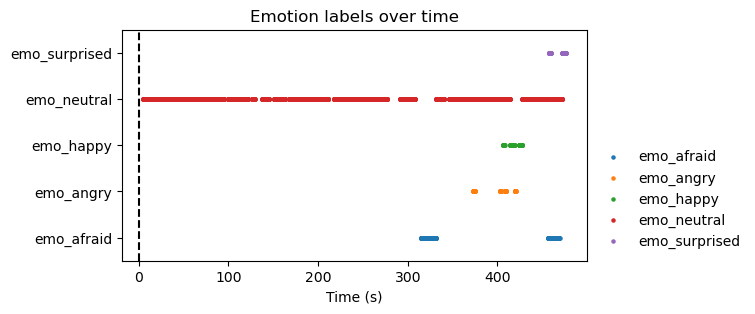

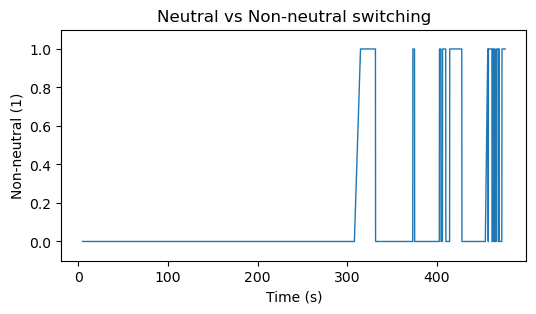

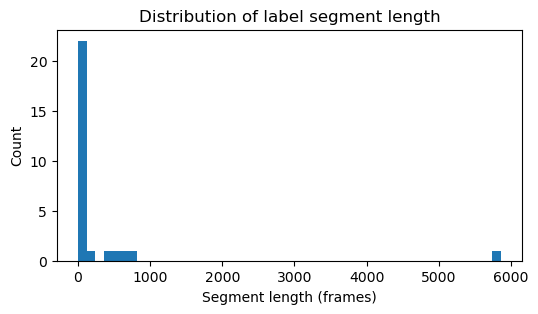

median: 47.0
short (<5 frames): 0.0


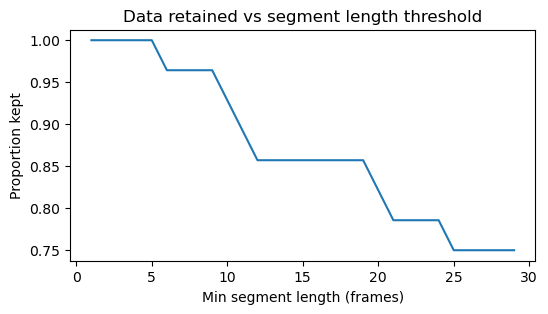

In [8]:
import matplotlib.pyplot as plt

emo_cols = [
    "emo_afraid",
    "emo_angry",
    "emo_happy",
    "emo_neutral",
    "emo_surprised"
]

t = df_face_note["movie_time"].values

# ===================================
# face emotion label check
# ===================================
plt.figure(figsize=(6, 3))

for i, col in enumerate(emo_cols):
    y = df_face_note[col].astype(int) * (i + 1)
    plt.scatter(t, y, s=5, label=col)

plt.axvline(0, color="black", linestyle="--")
plt.yticks(range(1, len(emo_cols)+1), emo_cols)
plt.ylim(0.5, len(emo_cols)+0.5)
plt.xlabel("Time (s)")
plt.title("Emotion labels over time")
plt.legend(bbox_to_anchor=(1.0,0), loc="lower left", frameon=False)
plt.show()

# ===================================
# face emotion switching
# ===================================
is_non_neutral = ~df_face_note["emo_neutral"]

plt.figure(figsize=(6, 3))
plt.plot(t, is_non_neutral.astype(int), linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Non-neutral (1)")
plt.title("Neutral vs Non-neutral switching")
plt.ylim(-0.1, 1.1)
plt.show()

# ===================================
# distribution check
# ===================================
labels = df_face_note["dominant_emotion"].values

segments = []
start = 0

for i in range(1, len(labels)):
    if labels[i] != labels[i-1]:
        segments.append((labels[i-1], start, i-1))
        start = i

segments.append((labels[-1], start, len(labels)-1))

lengths = [end - start + 1 for (_, start, end) in segments]

plt.figure(figsize=(6, 3))
plt.hist(lengths, bins=50)
plt.xlabel("Segment length (frames)")
plt.ylabel("Count")
plt.title("Distribution of label segment length")
plt.show()

print("median:", np.median(lengths))
print("short (<5 frames):", np.mean(np.array(lengths) < 5))

# ===================================
# screen check
# ===================================

lengths = np.array(lengths)

thresholds = np.arange(1, 30)
proportion = [(lengths >= th).mean() for th in thresholds]

plt.figure(figsize=(6, 3))
plt.plot(thresholds, proportion)
plt.xlabel("Min segment length (frames)")
plt.ylabel("Proportion kept")
plt.title("Data retained vs segment length threshold")
plt.show()

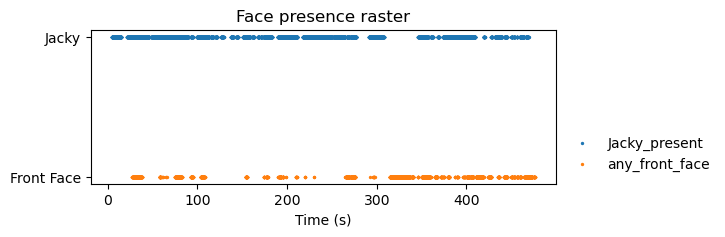

In [9]:
import matplotlib.pyplot as plt

t = df_face_note["movie_time"].values

jacky = df_face_note["Jacky_present"].astype(int).values
front = df_face_note["any_front_face"].astype(int).values

plt.figure(figsize=(6, 2))

plt.scatter(t[jacky == 1], [1]*np.sum(jacky==1), s=2, label="Jacky_present")
plt.scatter(t[front == 1], [0]*np.sum(front==1), s=2, label="any_front_face")

plt.yticks([0, 1], ["Front Face", "Jacky"])
plt.xlabel("Time (s)")
plt.title("Face presence raster")
plt.legend(bbox_to_anchor=(1.0,0), loc="lower left", frameon=False)
plt.show()

In [10]:
nwb_path = load_data_into_pds.find_nwb_file_for_subject(NWB_DIR, "CS41")
print("Using:", nwb_path)

io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
nwb = io.read()

print("\n=== acquisition keys ===")
print(list(nwb.acquisition.keys()))

print("\n=== processing modules ===")
print(list(nwb.processing.keys()))

for mod_name, mod in nwb.processing.items():
    print(f"\n--- processing[{mod_name}] keys ---")
    try:
        print(list(mod.data_interfaces.keys()))
    except Exception as e:
        print("cannot list data_interfaces:", e)

print("\n=== stimulus keys ===")
print(list(getattr(nwb, "stimulus", {}).keys()))

print("\n=== intervals ===")
print(list(getattr(nwb, "intervals", {}).keys()))

io.close()

Using: /Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb

=== acquisition keys ===
['events_ttl', 'experiment_ids']

=== processing modules ===
['behavior', 'ecephys']

--- processing[behavior] keys ---
['Blink', 'EyeTracking', 'Fixation', 'PupilTracking', 'Saccade']

--- processing[ecephys] keys ---
['LFP_macro', 'LFP_micro']

=== stimulus keys ===
['movieframe_time']

=== intervals ===
['trials']


In [11]:
from pynwb import NWBHDF5IO
io = NWBHDF5IO("/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb", "r", load_namespaces=True)
nwb = io.read()

ece = nwb.processing["ecephys"]
print("LFP_macro electrical_series keys:", list(ece["LFP_macro"].electrical_series.keys()))
print("LFP_micro electrical_series keys:", list(ece["LFP_micro"].electrical_series.keys()))

beh = nwb.processing["behavior"]
print("EyeTracking spatial_series keys:", list(beh["EyeTracking"].spatial_series.keys()))
print("PupilTracking time_series keys:", list(beh["PupilTracking"].time_series.keys()))

io.close()

LFP_macro electrical_series keys: ['ElectricalSeries']
LFP_micro electrical_series keys: ['ElectricalSeries']
EyeTracking spatial_series keys: ['SpatialSeries']
PupilTracking time_series keys: ['TimeSeries']


In [60]:
sub_nums = [41, 42, 43, 44, 47, 48, 49, 51, 53, 54, 55, 56, 57, 58, 60, 62]
# sub_nums = [41, 42, 43, 44, 47, 48, 49, 51, 53, 54, 55, 56, 57, 58, 60, 62]

filter_config = {
    "lfp_macro": [
        {"type": "bandstop", "low": 58, "high": 62, "order": 4},
        {"type": "bandstop", "low": 118, "high": 122, "order": 4},
        {"type": "bandpass", "low": 0.5, "high": 150, "order": 4},
    ],
    "lfp_micro": [
        {"type": "bandstop", "low": 58, "high": 62, "order": 4},
        {"type": "bandstop", "low": 118, "high": 122, "order": 4},
        {"type": "bandpass", "low": 0.5, "high": 150, "order": 4},
    ],
    "eye_gaze":  {"type": "lowpass",  "high": 20.0, "order": 4},
    "pupil":     {"type": "lowpass",  "high": 10.0, "order": 4},
}

data = load_data_into_dict.load_multimodal_subjects_movie_aligned(
    sub_nums=sub_nums,
    nwb_root=NWB_DIR,
    bids_root=BIDS_DIR,
    max_nwb_samples=2000000,
    b_filter_data=True,
    filter_config=filter_config,
    
    grid_source= "uniform",   # {"movie_frame_time", "uniform", "lfp_raw"}
    grid_dt = 0.004,         # used when grid_source == "uniform"
    uniform_grid_include_baseline = True,

    compute_firing_rate= True,
    firing_rate_bin_width= None,  # if None, infer from t_grid
    compute_lfp_bandpower= True,
    lfp_bandpower_on_raw= True,       # recommended
    bands= None,

    # optional fmri
    load_fmri= False,
    fmri_max_runs= None,
)

print(data[41].keys())
print(data[41]['meta'])
print(data[41]["lfp_macro"].shape, data[41]["eye_gaze"].shape)
# print("n_units:", data[41]["meta"]["n_units"], "firing_rate:", data[41]["firing_rate"].shape)
print("band keys:", list(data[41]["lfp_bandpower"].keys()))
# data[41]["lfp_macro"][:, :5]
x = data[41]["lfp_macro"]
t = data[41]["time_grid"]
print(x.shape, len(t))

[sub 41] t_eye_raw range=(0.000, 749.600)
[sub 41] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb
[sub 41] fs_macro=1000.0, fs_micro=1000.0, fs_eye=499.9999999976126
[sub 41] t_macro_movie range=(-10.000, 753.963)
[sub 41] movieframe_time(frame) range=(0.000, 11970.000)
[sub 41] movieframe_time_sec range=(0.000, 478.800)
[sub 41] t_grid len=190992 source=uniform
[sub 42] t_eye_raw range=(0.001, 813.863)
[sub 42] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS42/sub-CS42_ses-P42CSR1_behavior+ecephys.nwb
[sub 42] fs_macro=1000.0, fs_micro=1000.0, fs_eye=499.9999999976126
[sub 42] t_macro_movie range=(-10.000, 814.068)
[sub 42] movieframe_time(frame) range=(0.000, 11970.000)
[sub 42] movieframe_time_sec range=(0.000, 478.800)
[sub 42] t_grid len=206018 source=uniform
[sub 43] t_eye_raw range=(0.000, 823.604)
[sub 43] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/00062

In [61]:
eye_data = data[41]["eye_gaze"]
print("movie_time shape:", data[41]["movieframe_time"].shape)
print("eye_gaze shape:", eye_data.shape)
print(eye_data[:5])

movie_time shape: (11971,)
eye_gaze shape: (190992, 2)
[[630.07562256 548.12335205]
 [630.07562256 548.12335205]
 [630.07562256 548.12335205]
 [630.07562256 548.12335205]
 [630.07562256 548.12335205]]


Text(0.5, 1.0, 'PCA Explained Variance')

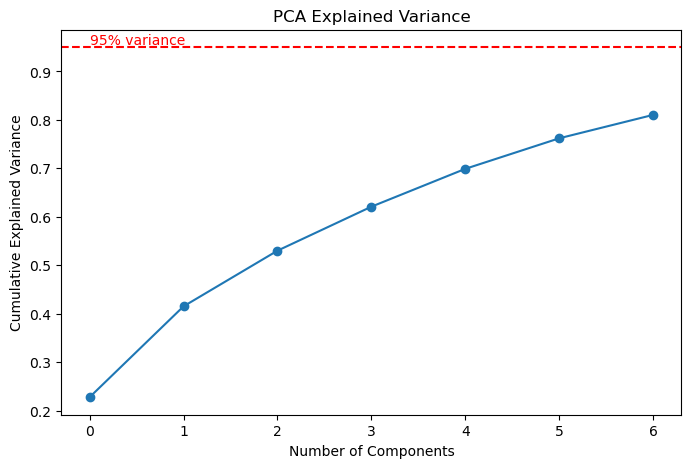

In [62]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

seg = slicer.slice_modalities_by_movie_time_sec(data[41], 0.0, 10.0)

X = seg["lfp_micro"]

X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(
    y=0.95,
    color='r',
    linestyle='--',
    label='95% variance'
)

plt.text(
    x=0,
    y=0.95,
    s="95% variance",
    color='r',
    ha='left',
    va='bottom'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

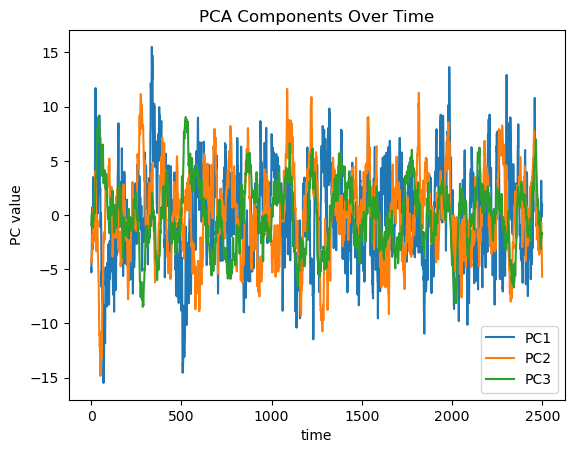

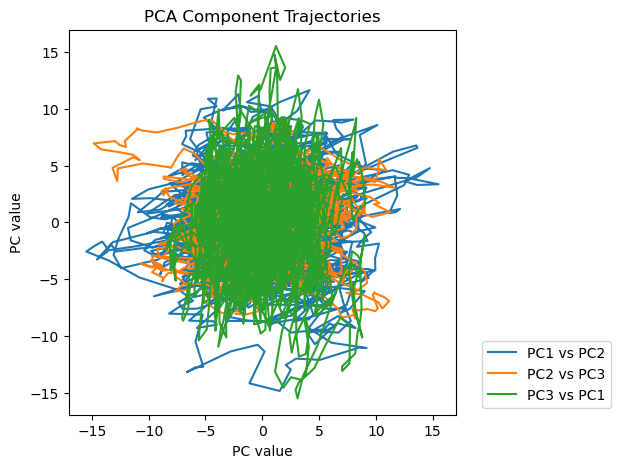

In [63]:
import matplotlib.pyplot as plt

for i in range(3):
    plt.plot(X_pca[:, i], label=f'PC{i+1}')

plt.legend()
plt.xlabel("time")
plt.ylabel("PC value")
plt.title("PCA Components Over Time")
plt.show()

plt.figure(figsize=(5, 5))
for i in range(3):
    j = (i + 1) % 3
    plt.plot(X_pca[:, i], X_pca[:, j],label=f'PC{i+1} vs PC{j+1}')
    

plt.legend(bbox_to_anchor=(1.05, 0), loc='lower left')
plt.xlabel("PC value")
plt.ylabel("PC value")
plt.title("PCA Component Trajectories")
plt.axis('equal')
plt.show()

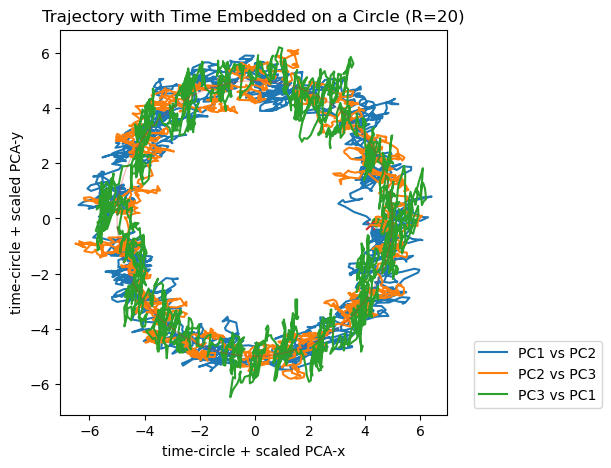

In [64]:
import numpy as np
import matplotlib.pyplot as plt

R = 5
T = X_pca.shape[0]
theta = np.linspace(0, 2*np.pi, T, endpoint=True)

plt.figure(figsize=(5, 5))

for i in range(3):
    j = (i + 1) % 3

    x = X_pca[:, i]
    y = X_pca[:, j]

    p95 = np.percentile(np.sqrt(x**2 + y**2), 95)
    s = (0.25 * R) / (p95 + 1e-9)

    cx = R * np.cos(theta)
    cy = R * np.sin(theta)

    X = cx + s * x
    Y = cy + s * y

    plt.plot(X, Y, label=f'PC{i+1} vs PC{j+1}')

    plt.scatter(X[0],  Y[0],  s=40, marker='o')
    plt.scatter(X[-1], Y[-1], s=40, marker='x')

tt = np.linspace(0, 2*np.pi, 400)
plt.plot(R*np.cos(tt), R*np.sin(tt), linewidth=1, alpha=0.3)

plt.legend(bbox_to_anchor=(1.05, 0), loc='lower left')
plt.axis('equal')
plt.xlabel("time-circle + scaled PCA-x")
plt.ylabel("time-circle + scaled PCA-y")
plt.title("Trajectory with Time Embedded on a Circle (R=20)")
plt.show()

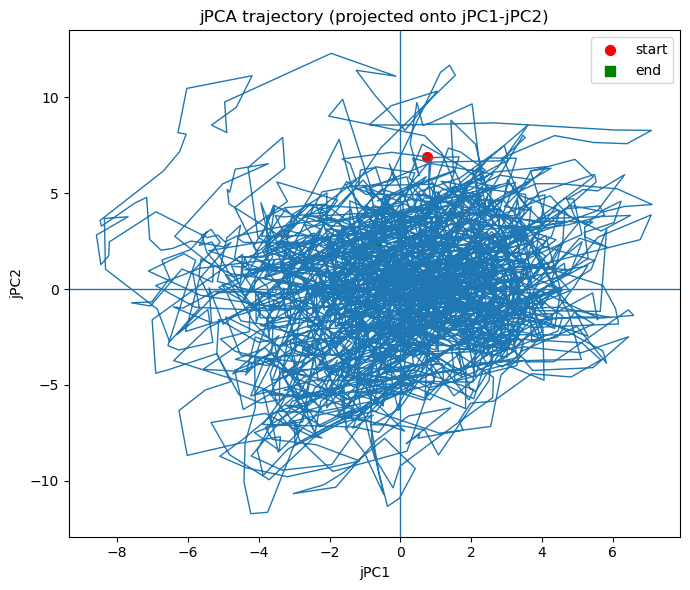

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def finite_diff(X, dt=1.0):
    """Centered finite difference for dX/dt (same length as X)."""
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
    dX[0]    = (X[1] - X[0]) / dt
    dX[-1]   = (X[-1] - X[-2]) / dt
    return dX

def fit_skew_M(X, dX):
    """
    Fit skew-symmetric M to minimize ||dX - X M^T||_F
    with constraint M^T = -M.
    """
    T, D = X.shape
    assert dX.shape == X.shape

    # Build linear system A m = b for upper-triangular free params of M
    # Parameterize M by entries m_ij for i<j, with:
    # M[i,j]=m_ij, M[j,i]=-m_ij, diag=0.
    pairs = [(i, j) for i in range(D) for j in range(i+1, D)]
    P = len(pairs)

    A = np.zeros((T * D, P), dtype=float)
    b = dX.reshape(-1)

    # For each time t and row k:
    # (X M^T)[t,k] = sum_l X[t,l] * M[k,l]
    # and M[k,l] expressed via m_ij.
    row = 0
    for t in range(T):
        x = X[t]
        for k in range(D):
            for p_idx, (i, j) in enumerate(pairs):
                val = 0.0
                # contribution from M[k,i] and M[k,j] if they exist
                # M[k,l] is:
                #  - if k==i and l==j: +m_ij
                #  - if k==j and l==i: -m_ij
                #  - if k==j and l==i handled similarly, etc.
                if k == i:
                    # term X[t, j] * M[i, j] = X_j * (+m_ij)
                    val += x[j]
                elif k == j:
                    # term X[t, i] * M[j, i] = X_i * (-m_ij)
                    val -= x[i]
                # also need terms where l==k and k==i/j? already covered above (since M[k,l])
                A[row, p_idx] = val
            row += 1

    # Solve least squares
    m_hat, *_ = np.linalg.lstsq(A, b, rcond=None)

    # Reconstruct M
    D = X.shape[1]
    M = np.zeros((D, D), dtype=float)
    for p_idx, (i, j) in enumerate(pairs):
        M[i, j] = m_hat[p_idx]
        M[j, i] = -m_hat[p_idx]
    return M

def jpca(X, dt=1.0, center=True):
    """
    X: (T, D) single trajectory (time-ordered).
    Returns:
      Xc: centered X used for fit
      M: skew-symmetric fitted dynamics
      W: (D,2) jPC plane basis
      Z: (T,2) projected trajectory in jPC plane
    """
    X_use = X.copy()
    if center:
        X_use = X_use - X_use.mean(axis=0, keepdims=True)

    dX = finite_diff(X_use, dt=dt)
    M = fit_skew_M(X_use, dX)

    # For skew-symmetric M, eigenvalues are ± iω. Take the pair with largest |ω|.
    evals, evecs = np.linalg.eig(M)
    omegas = np.abs(np.imag(evals))
    idx = np.argsort(omegas)[::-1]

    # pick the first eigenvector; its conjugate spans the same 2D plane
    v = evecs[:, idx[0]]
    W = np.column_stack([np.real(v), np.imag(v)])  # (D,2)

    # Orthonormalize W
    W, _ = np.linalg.qr(W)

    Z = X_use @ W
    return X_use, M, W, Z

# ====== X_pca jPCA ======
X = X_pca[:, :6]
dt = 1/30

Xc, M, W, Z = jpca(X, dt=dt, center=True)

# ====== jPC1 vs jPC2 ======
plt.figure(figsize=(7, 6))
plt.plot(Z[:, 0], Z[:, 1], lw=1)
plt.scatter(Z[0, 0], Z[0, 1], s=50, color='red', marker='o', label='start')
plt.scatter(Z[-1, 0], Z[-1, 1], s=50, color='green', marker='s', label='end')
plt.axhline(0, lw=1)
plt.axvline(0, lw=1)
plt.xlabel("jPC1")
plt.ylabel("jPC2")
plt.title("jPCA trajectory (projected onto jPC1-jPC2)")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Face Encoding Model
## 4.1 Feature Engineering

In [66]:
norm_modality_dict = {
    "firing_rate": [True, "max"],
    "lfp_macro": [False, "zscore"],
    "lfp_micro": [False, "zscore"],
    "eye_gaze": [True, "min_max"],
    "pupil": [True, "max"],
}

all_window_data = feature.build_all_subject_window_datasets(
    out=data,
    df_face_note=df_face_note,
    window_size_sec=0.5,          # 500 ms
    stride_sec=0.25,               # 100 ms stride
    start_time=0.0,
    end_time=478.800,
    remove_baseline_windows=True,
    do_baseline_norm=True,
    norm_modality_dict=norm_modality_dict,
    baseline_mode="zscore",
    baseline_start=-10.0,
    baseline_end=0.0,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    use_only_valid_face_frames=True,
    valid_face_mode="front_or_face",
    require_all_modalities_nonempty=False,
    verbose=True,
)

all_window_data_filtered = {}

# filter valid window, face ratio, min_frame
for sub, sub_data in all_window_data.items():
    all_window_data_filtered[sub] = feature.filter_window_dataset(
        sub_data,
        valid_window_only=True,
        min_valid_face_ratio=0.25,
        min_face_frames=5,
        min_non_neutral=None,
        allowed_hard_labels=None,
        require_modalities_nonempty=["firing_rate"],
        verbose=True,
    )

concat_data = feature.concat_subject_window_data(
    all_window_data_filtered,
    subjects=None,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    add_subject_column=True,
    reset_index=True,
    verbose=True,
)

[build] subject 41
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 42
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 43
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 44
normalized modality 'lfp_macro' with baseline mode 'zscore' using 2500 baseline samples.
normalized modality 'lfp_micro' with baseline mode 'zscore' using 2500 baseline samples.
  -> n_windows = 1914, valid_windows = 1914
[build] subject 47
normalized modali

In [67]:
print(concat_data["window_df"].columns)

Index(['sub', 'window_start', 'window_end', 'n_timepoints', 'valid_window',
       'n_face_frames_total', 'emo_afraid', 'emo_angry', 'emo_happy',
       'emo_neutral', 'emo_surprised', 'p_non_neutral', 'hard_label',
       'valid_face_ratio', 'front_face_ratio', 'jacky_ratio', 'mean_n_faces'],
      dtype='str')


[lfp_micro] [sub=41] split by: emo
[lfp_micro] [sub=41] neutral windows: 1321
[lfp_micro] [sub=41] nonneutral windows: 199
[lfp_micro] [sub=41] shared explained variance ratio: [0.27321553 0.2095517  0.12445735 0.0893801  0.07466349]
[lfp_micro] [sub=42] split by: emo
[lfp_micro] [sub=42] neutral windows: 1321
[lfp_micro] [sub=42] nonneutral windows: 199
[lfp_micro] [sub=42] shared explained variance ratio: [0.13450624 0.09855627 0.0699889  0.06576151 0.05366674]
[lfp_micro] [sub=43] split by: emo
[lfp_micro] [sub=43] neutral windows: 1321
[lfp_micro] [sub=43] nonneutral windows: 199
[lfp_micro] [sub=43] shared explained variance ratio: [0.25019813 0.14676856 0.13556158 0.08040343 0.0675092 ]
[lfp_micro] [sub=44] split by: emo
[lfp_micro] [sub=44] neutral windows: 1321
[lfp_micro] [sub=44] nonneutral windows: 199
[lfp_micro] [sub=44] shared explained variance ratio: [0.21737428 0.13175909 0.08177005 0.07317767 0.06258061]
[lfp_micro] [sub=47] split by: emo
[lfp_micro] [sub=47] neutral 

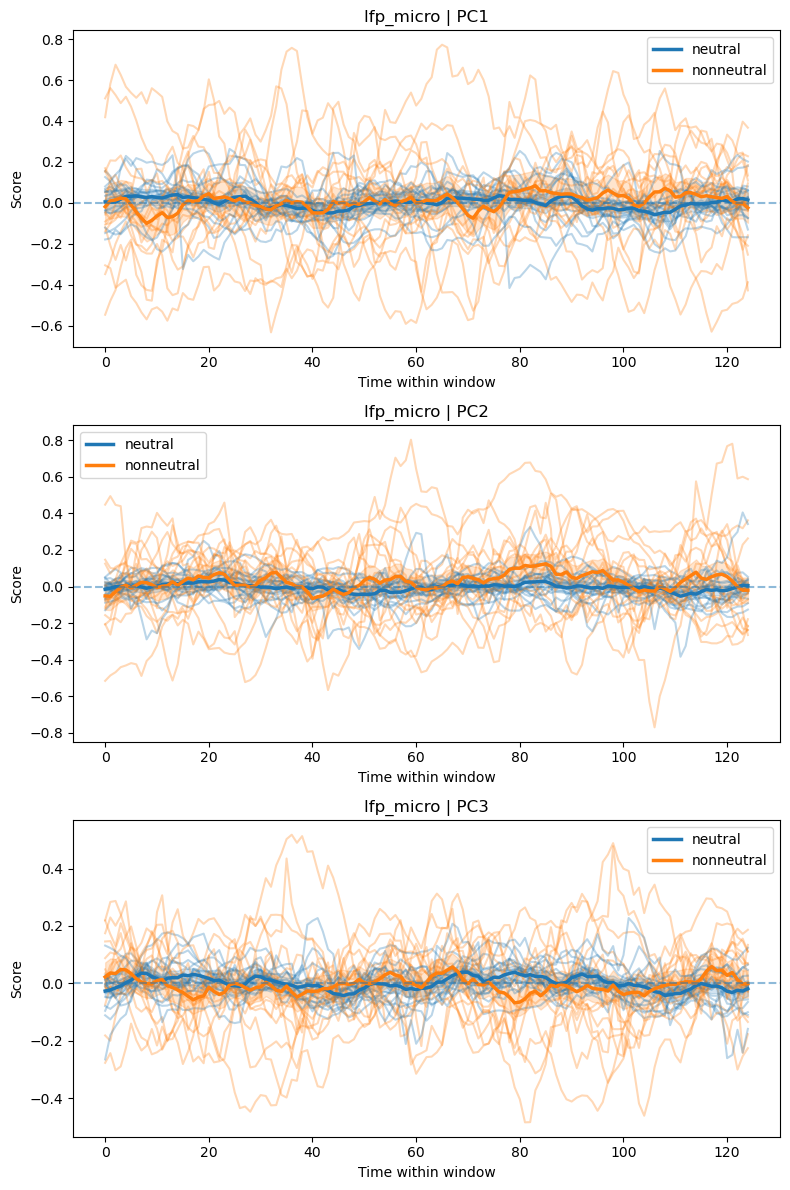

=== Decoding results ===
Groups: neutral vs nonneutral
Mode: time_mean
Total samples: 24320
Total subjects: 16

[Logistic Regression]
Acc: 0.499 ± 0.002
AUC: 0.485 ± 0.009

[SVM]
Acc: 0.869 ± 0.000
AUC: 0.499 ± 0.009
=== Decoding results ===
Groups: neutral vs nonneutral
Mode: stats
Total samples: 24320
Total subjects: 16

[Logistic Regression]
Acc: 0.482 ± 0.006
AUC: 0.511 ± 0.004

[SVM]
Acc: 0.869 ± 0.000
AUC: 0.497 ± 0.004


{'logreg': {'acc': array([0.47779605, 0.47861842, 0.47759046, 0.49157072, 0.48560855]),
  'auc': array([0.51608623, 0.51194775, 0.51164433, 0.5043588 , 0.51078308])},
 'svm': {'acc': array([0.86924342, 0.86903783, 0.86903783, 0.86903783, 0.86903783]),
  'auc': array([0.49620752, 0.49539348, 0.49574853, 0.50393282, 0.49205247])},
 'X': array([[-1.92061868,  1.54293781,  0.71530665, ..., -1.1070296 ,
          0.04243039, -0.55201505],
        [-0.24281216, -1.05029039,  0.64339099, ..., -0.14355753,
          0.99171007,  0.14746393],
        [ 0.13138479, -3.49740253,  0.38037937, ..., -0.75115158,
         -2.3568761 ,  0.68623006],
        ...,
        [ 0.03019189, -0.71235581, -0.04411593, ...,  0.11431599,
         -1.15952698,  1.327425  ],
        [ 0.97880266, -0.62235766,  0.77323175, ...,  0.89305474,
          1.4898603 ,  0.08050965],
        [ 0.13000315, -0.58483404,  0.47766023, ..., -0.92464333,
          0.40216167, -1.09715256]], shape=(24320, 25)),
 'y': array([0, 0,

In [68]:
pca_res = decompose.run_grouped_trajectory_pca_on_concat_data(concat_data, modality="lfp_micro", n_components=5, split_by_sub=True)

# decompose.plot_grouped_pca_across_sub(pca_res, pcx=1, pcy=2, alpha=0.3, equal_axis=True)
# decompose.plot_grouped_pca_across_sub(pca_res, pcx=2, pcy=3, alpha=0.3, equal_axis=True)
decompose.plot_pc_time_series_across_sub(pca_res)

decompose.run_decoding_on_pca_res(pca_res, mode="time_mean")
decompose.run_decoding_on_pca_res(pca_res, mode="stats")
# decompose.run_decoding_on_pca_res(pca_res, mode="channel_mean")

0.0 1.0
[lfp_micro] [sub=41] split by: jacky
[lfp_micro] [sub=41] no_jacky windows: 366
[lfp_micro] [sub=41] jacky_present windows: 1154
[lfp_micro] [sub=41] shared explained variance ratio: [0.27321553 0.2095517  0.12445735 0.0893801  0.07466349]
0.0 1.0
[lfp_micro] [sub=42] split by: jacky
[lfp_micro] [sub=42] no_jacky windows: 366
[lfp_micro] [sub=42] jacky_present windows: 1154
[lfp_micro] [sub=42] shared explained variance ratio: [0.13450624 0.09855627 0.0699889  0.06576151 0.05366674]
0.0 1.0
[lfp_micro] [sub=43] split by: jacky
[lfp_micro] [sub=43] no_jacky windows: 366
[lfp_micro] [sub=43] jacky_present windows: 1154
[lfp_micro] [sub=43] shared explained variance ratio: [0.25019813 0.14676856 0.13556158 0.08040343 0.0675092 ]
0.0 1.0
[lfp_micro] [sub=44] split by: jacky
[lfp_micro] [sub=44] no_jacky windows: 366
[lfp_micro] [sub=44] jacky_present windows: 1154
[lfp_micro] [sub=44] shared explained variance ratio: [0.21737428 0.13175909 0.08177005 0.07317767 0.06258061]
0.0 1.0


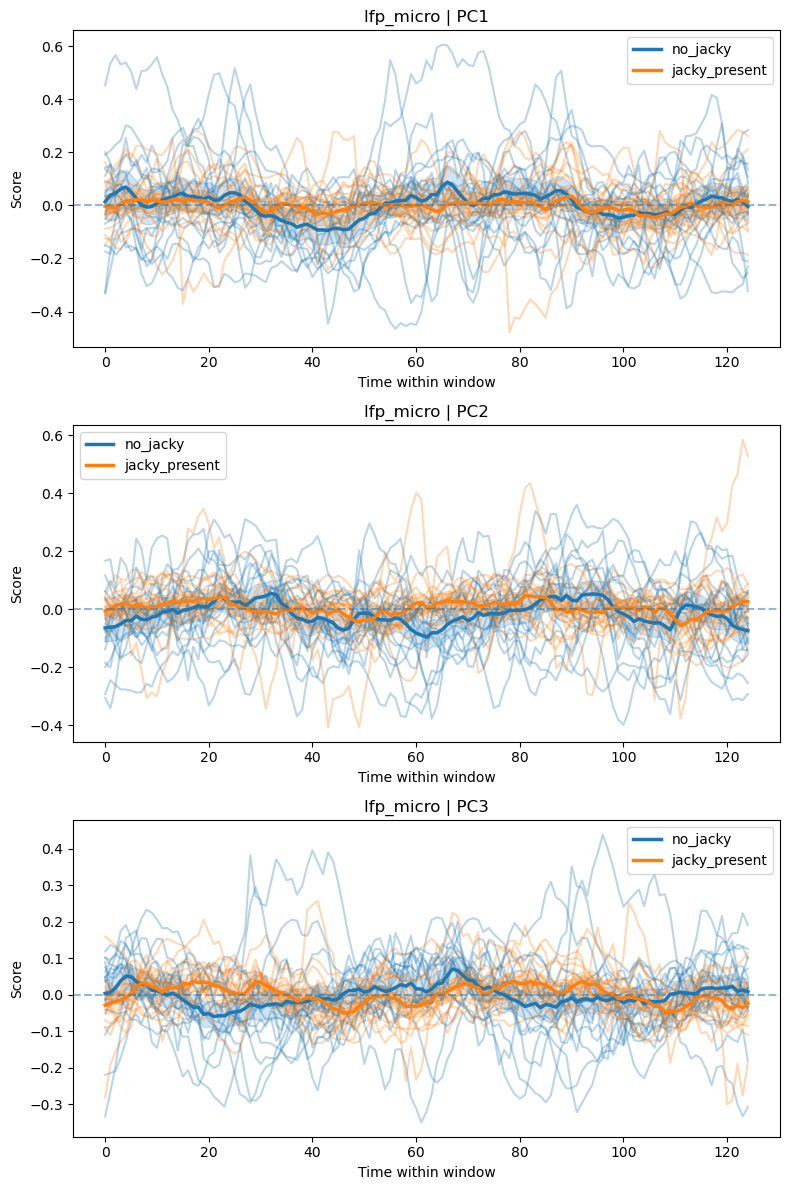

=== Decoding results ===
Groups: no_jacky vs jacky_present
Mode: time_mean
Total samples: 24320
Total subjects: 16

[Logistic Regression]
Acc: 0.499 ± 0.006
AUC: 0.494 ± 0.010

[SVM]
Acc: 0.759 ± 0.000
AUC: 0.508 ± 0.003
=== Decoding results ===
Groups: no_jacky vs jacky_present
Mode: stats
Total samples: 24320
Total subjects: 16

[Logistic Regression]
Acc: 0.481 ± 0.010
AUC: 0.512 ± 0.017

[SVM]
Acc: 0.759 ± 0.000
AUC: 0.496 ± 0.016


{'logreg': {'acc': array([0.47902961, 0.49300987, 0.48314145, 0.48519737, 0.46402138]),
  'auc': array([0.50941571, 0.54056663, 0.50466909, 0.5178824 , 0.48888531])},
 'svm': {'acc': array([0.75904605, 0.75925164, 0.75925164, 0.75925164, 0.75925164]),
  'auc': array([0.49790595, 0.50057244, 0.52220706, 0.48807204, 0.47210049])},
 'X': array([[-2.41757888, -0.30746573, -0.58735853, ...,  0.45069058,
         -0.45952116,  0.98902855],
        [-1.5086005 ,  1.61837147, -0.89147673, ...,  0.16916404,
         -1.01677196,  0.53976776],
        [ 0.91113176,  0.02017137,  0.30604148, ...,  1.55142044,
         -0.2090806 , -0.01870095],
        ...,
        [-0.88515727, -0.87263663,  0.92889833, ...,  1.40356433,
         -0.99764962,  0.35722877],
        [-1.39899225, -1.02064716,  1.99270668, ...,  0.46213762,
         -0.3332501 , -1.08988846],
        [-0.66971865,  0.02175835,  1.21632469, ..., -0.30831255,
          0.33430383, -0.31268002]], shape=(24320, 25)),
 'y': array([0, 0,

In [69]:
pca_res = decompose.run_grouped_trajectory_pca_on_concat_data(concat_data, spliter="jacky", eps=1.0, modality="lfp_micro", n_components=5, split_by_sub=True)

# decompose.plot_grouped_pca_across_sub(pca_res, pcx=1, pcy=2, alpha=0.3, equal_axis=True)
# decompose.plot_grouped_pca_across_sub(pca_res, pcx=2, pcy=3, alpha=0.3, equal_axis=True)
decompose.plot_pc_time_series_across_sub(pca_res)

decompose.run_decoding_on_pca_res(pca_res, mode="time_mean")
decompose.run_decoding_on_pca_res(pca_res, mode="stats")
# decompose.run_decoding_on_pca_res(pca_res, mode="bandpower")
# decompose.run_decoding_on_pca_res(pca_res, mode="channel_mean")

[lfp_micro] [sub=41] split by: front_face
[lfp_micro] [sub=41] no_front_face windows: 1111
[lfp_micro] [sub=41] front_face_present windows: 409
[lfp_micro] [sub=41] shared explained variance ratio: [0.27321553 0.2095517  0.12445735 0.0893801  0.07466349]
[lfp_micro] [sub=42] split by: front_face
[lfp_micro] [sub=42] no_front_face windows: 1111
[lfp_micro] [sub=42] front_face_present windows: 409
[lfp_micro] [sub=42] shared explained variance ratio: [0.13450624 0.09855627 0.0699889  0.06576151 0.05366674]
[lfp_micro] [sub=43] split by: front_face
[lfp_micro] [sub=43] no_front_face windows: 1111
[lfp_micro] [sub=43] front_face_present windows: 409
[lfp_micro] [sub=43] shared explained variance ratio: [0.25019813 0.14676856 0.13556158 0.08040343 0.0675092 ]
[lfp_micro] [sub=44] split by: front_face
[lfp_micro] [sub=44] no_front_face windows: 1111
[lfp_micro] [sub=44] front_face_present windows: 409
[lfp_micro] [sub=44] shared explained variance ratio: [0.21737428 0.13175909 0.08177005 0.0

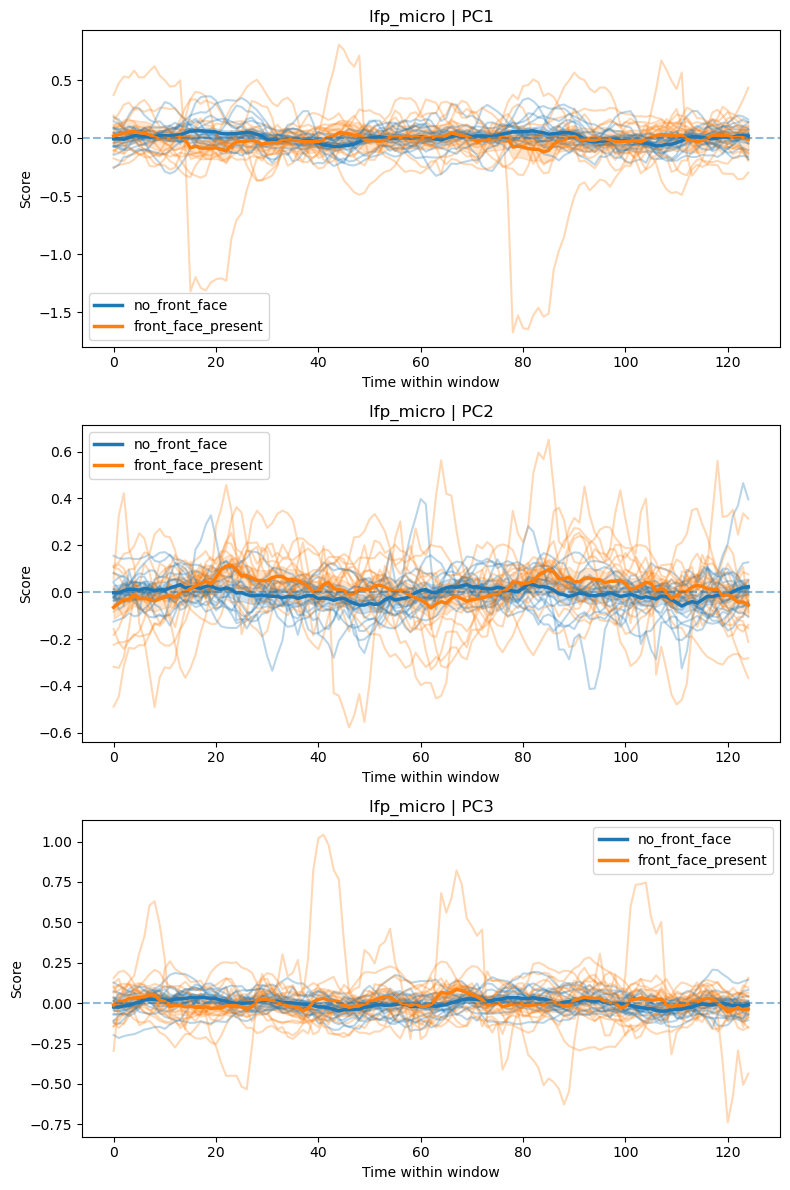

=== Decoding results ===
Groups: no_front_face vs front_face_present
Mode: time_mean
Total samples: 24320
Total subjects: 16

[Logistic Regression]
Acc: 0.498 ± 0.010
AUC: 0.493 ± 0.009

[SVM]
Acc: 0.731 ± 0.000
AUC: 0.497 ± 0.004
=== Decoding results ===
Groups: no_front_face vs front_face_present
Mode: stats
Total samples: 24320
Total subjects: 16

[Logistic Regression]
Acc: 0.504 ± 0.010
AUC: 0.509 ± 0.007

[SVM]
Acc: 0.731 ± 0.000
AUC: 0.494 ± 0.007


{'logreg': {'acc': array([0.49609375, 0.49835526, 0.51912007, 0.51315789, 0.49321546]),
  'auc': array([0.50697103, 0.4962771 , 0.51600722, 0.51394038, 0.50972527])},
 'svm': {'acc': array([0.73108553, 0.73087993, 0.73087993, 0.73087993, 0.73087993]),
  'auc': array([0.4893721 , 0.50592275, 0.48628031, 0.49841807, 0.48983055])},
 'X': array([[-1.92061868,  1.54293781,  0.71530665, ..., -1.1070296 ,
          0.04243039, -0.55201505],
        [-0.24281216, -1.05029039,  0.64339099, ..., -0.14355753,
          0.99171007,  0.14746393],
        [ 0.13138479, -3.49740253,  0.38037937, ..., -0.75115158,
         -2.3568761 ,  0.68623006],
        ...,
        [ 0.03019189, -0.71235581, -0.04411593, ...,  0.11431599,
         -1.15952698,  1.327425  ],
        [ 0.97880266, -0.62235766,  0.77323175, ...,  0.89305474,
          1.4898603 ,  0.08050965],
        [ 0.13000315, -0.58483404,  0.47766023, ..., -0.92464333,
          0.40216167, -1.09715256]], shape=(24320, 25)),
 'y': array([0, 0,

In [70]:
pca_res = decompose.run_grouped_trajectory_pca_on_concat_data(concat_data, spliter="front_face", eps=1.0, modality="lfp_micro", n_components=5, split_by_sub=True)

# decompose.plot_grouped_pca_across_sub(pca_res, pcx=1, pcy=2, alpha=0.3, equal_axis=True)
# decompose.plot_grouped_pca_across_sub(pca_res, pcx=2, pcy=3, alpha=0.3, equal_axis=True)
decompose.plot_pc_time_series_across_sub(pca_res)

decompose.run_decoding_on_pca_res(pca_res, mode="time_mean")
decompose.run_decoding_on_pca_res(pca_res, mode="stats")
# decompose.run_decoding_on_pca_res(pca_res, mode="channel_mean")

## 4.2 Modality Fusion
### 4.2.1 Feature Summary

[split] sub=41: n_windows=1520
[split] sub=42: n_windows=1520
[split] sub=43: n_windows=1520
[split] sub=44: n_windows=1520
[split] sub=47: n_windows=1520
[split] sub=48: n_windows=1520
[split] sub=49: n_windows=1520
[split] sub=51: n_windows=1520
[split] sub=53: n_windows=1520
[split] sub=54: n_windows=1520
[split] sub=55: n_windows=1520
[split] sub=56: n_windows=1520
[split] sub=57: n_windows=1520
[split] sub=58: n_windows=1520
[split] sub=60: n_windows=1520
[split] sub=62: n_windows=1520
[firing_rate] X.shape=(1520, 77), valid=1520/1520
[lfp_macro] X.shape=(1520, 1056), valid=1520/1520
[lfp_micro] X.shape=(1520, 880), valid=1520/1520
[eye_gaze] X.shape=(1520, 22), valid=1520/1520
[pupil] X.shape=(1520, 11), valid=1520/1520
[subject PCA] sub=41, mod=firing_rate, X_use.shape=(1520, 77), Z.shape=(1520, 10)
[subject PCA] sub=41, mod=lfp_macro, X_use.shape=(1520, 1056), Z.shape=(1520, 10)
[subject PCA] sub=41, mod=lfp_micro, X_use.shape=(1520, 880), Z.shape=(1520, 10)
[subject PCA] sub=4

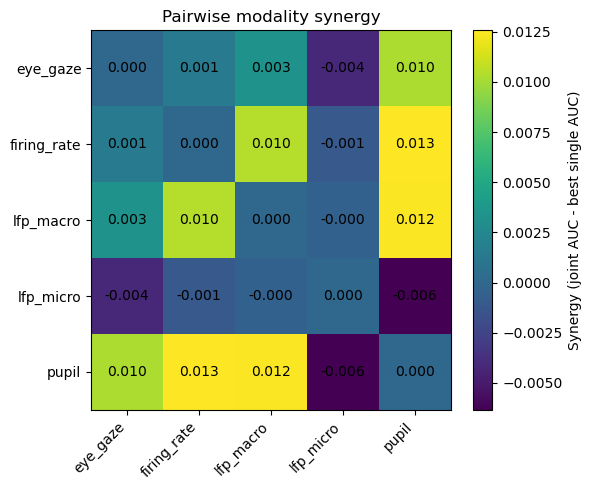

In [71]:
subject_latent_res = new_fusion.build_subjectwise_modality_latents(
    concat_data,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    feature_mode="stats_bandpower",
    pca_dim=10,
    sub_col="sub",
    verbose=True,
)

y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="emo_neutral",
    sub_col="sub",
)

stacked_latent = new_fusion.stack_subjectwise_latents(
    subject_latent_res,
    y_dict=y_dict,
    verbose=True,
)

syn_res = new_fusion.compute_pairwise_synergy_matrix_from_latents(
    stacked_latent,
    cv=5,
    verbose=True,
)

new_fusion.plot_synergy_matrix(syn_res)

## AUC Sanity Checking

In [72]:
import numpy as np
import pandas as pd
from itertools import combinations

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score


def _cv_auc(X, y, cv=5, random_state=42):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    model = make_pipeline(
        SimpleImputer(strategy="mean"),
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced")
    )

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    aucs = cross_val_score(model, X, y, cv=skf, scoring="roc_auc")
    return float(np.mean(aucs)), float(np.std(aucs))


def sanity_check_single_modalities_multisub(
    feat_dict_by_sub,
    valid_mask_dict_by_sub,
    y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    min_windows=10,
    return_per_subject=True,
    verbose=True,
):
    """
    Parameters
    ----------
    feat_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub, F], mod2: ...},
            sub2: ...
        }

    valid_mask_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub] bool, mod2: ...},
            sub2: ...
        }

    y_dict : dict
        {
            sub1: [N_sub],
            sub2: [N_sub],
            ...
        }

    Returns
    -------
    summary_df : DataFrame
        one row per modality, aggregated across subjects

    per_sub_df : DataFrame
        one row per subject x modality
    """
    rng = np.random.default_rng(random_state)

    all_mods = sorted(list(set(
        m for sub in feat_dict_by_sub
        for m in feat_dict_by_sub[sub].keys()
    )))

    rows = []

    for sub in sorted(feat_dict_by_sub.keys()):
        if sub not in valid_mask_dict_by_sub:
            continue
        if sub not in y_dict:
            continue

        y = np.asarray(y_dict[sub])

        for mod in all_mods:
            if mod not in feat_dict_by_sub[sub]:
                continue
            if mod not in valid_mask_dict_by_sub[sub]:
                continue

            X = np.asarray(feat_dict_by_sub[sub][mod], dtype=float)
            mask = np.asarray(valid_mask_dict_by_sub[sub][mod], dtype=bool)

            if len(mask) != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: len(mask)={len(mask)} != len(y)={len(y)}"
                )
            if X.shape[0] != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: X.shape[0]={X.shape[0]} != len(y)={len(y)}"
                )

            mask = mask & np.isfinite(y)
            X_use = X[mask]
            y_use = y[mask]

            n_windows = int(mask.sum())
            n_classes = len(np.unique(y_use))

            if n_windows < max(cv, min_windows):
                if verbose:
                    print(f"[skip] sub={sub}, mod={mod}: too few windows ({n_windows})")
                continue

            if n_classes < 2:
                if verbose:
                    print(f"[skip] sub={sub}, mod={mod}: only one class")
                continue

            try:
                auc_mean, auc_std = _cv_auc(X_use, y_use, cv=cv, random_state=random_state)
            except Exception as e:
                if verbose:
                    print(f"[skip] sub={sub}, mod={mod}: CV failed ({e})")
                continue

            perm_aucs = []
            for _ in range(n_perm):
                y_perm = rng.permutation(y_use)
                try:
                    a, _ = _cv_auc(X_use, y_perm, cv=cv, random_state=random_state)
                    perm_aucs.append(a)
                except Exception:
                    pass

            perm_auc_mean = np.mean(perm_aucs) if len(perm_aucs) > 0 else np.nan
            perm_auc_std = np.std(perm_aucs) if len(perm_aucs) > 0 else np.nan

            rows.append({
                "sub": sub,
                "modality": mod,
                "n_windows": n_windows,
                "n_features": int(X_use.shape[1]),
                "auc_mean": auc_mean,
                "auc_std": auc_std,
                "perm_auc_mean": perm_auc_mean,
                "perm_auc_std": perm_auc_std,
                "delta_over_perm": auc_mean - perm_auc_mean if np.isfinite(perm_auc_mean) else np.nan,
            })

            if verbose:
                print(
                    f"[sub={sub}][{mod}] "
                    f"AUC={auc_mean:.4f}±{auc_std:.4f}, "
                    f"perm={perm_auc_mean:.4f}±{perm_auc_std:.4f}, "
                    f"delta={auc_mean - perm_auc_mean:.4f}"
                )

    per_sub_df = pd.DataFrame(rows)

    if len(per_sub_df) == 0:
        empty_cols = [
            "modality", "n_subjects", "mean_n_windows", "mean_n_features",
            "auc_mean_across_sub", "auc_std_across_sub",
            "perm_auc_mean_across_sub", "perm_auc_std_across_sub",
            "delta_over_perm_across_sub"
        ]
        summary_df = pd.DataFrame(columns=empty_cols)
        return (summary_df, per_sub_df) if return_per_subject else summary_df

    summary_df = (
        per_sub_df
        .groupby("modality", observed=True)
        .agg(
            n_subjects=("sub", "nunique"),
            mean_n_windows=("n_windows", "mean"),
            mean_n_features=("n_features", "mean"),
            auc_mean_across_sub=("auc_mean", "mean"),
            auc_std_across_sub=("auc_mean", "std"),
            perm_auc_mean_across_sub=("perm_auc_mean", "mean"),
            perm_auc_std_across_sub=("perm_auc_mean", "std"),
            delta_over_perm_across_sub=("delta_over_perm", "mean"),
        )
        .reset_index()
        .sort_values("auc_mean_across_sub", ascending=False)
        .reset_index(drop=True)
    )

    return (summary_df, per_sub_df) if return_per_subject else summary_df

def sanity_check_pairwise_synergy_multisub(
    feat_dict_by_sub,
    valid_mask_dict_by_sub,
    y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    min_windows=10,
    return_per_subject=True,
    verbose=True,
):
    """
    Multi-subject pairwise synergy check.

    Parameters
    ----------
    feat_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub, F], mod2: ...},
            sub2: ...
        }

    valid_mask_dict_by_sub : dict
        {
            sub1: {mod1: [N_sub] bool, mod2: ...},
            sub2: ...
        }

    y_dict : dict
        {
            sub1: [N_sub],
            sub2: [N_sub],
            ...
        }

    Returns
    -------
    summary_df : DataFrame
        aggregated over subjects, one row per modality pair

    per_sub_df : DataFrame
        one row per subject x modality pair
    """
    rng = np.random.default_rng(random_state)

    all_mods = sorted(list(set(
        m for sub in feat_dict_by_sub
        for m in feat_dict_by_sub[sub].keys()
    )))

    rows = []

    for sub in sorted(feat_dict_by_sub.keys()):
        if sub not in valid_mask_dict_by_sub:
            continue
        if sub not in y_dict:
            continue

        feat_dict = feat_dict_by_sub[sub]
        valid_mask_dict = valid_mask_dict_by_sub[sub]
        y = np.asarray(y_dict[sub])

        # single-modality AUC
        single_auc = {}

        for mod in all_mods:
            if mod not in feat_dict or mod not in valid_mask_dict:
                single_auc[mod] = np.nan
                continue

            X = np.asarray(feat_dict[mod], dtype=float)
            mask = np.asarray(valid_mask_dict[mod], dtype=bool)

            if len(mask) != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: len(mask)={len(mask)} != len(y)={len(y)}"
                )
            if X.shape[0] != len(y):
                raise ValueError(
                    f"sub={sub}, mod={mod}: X.shape[0]={X.shape[0]} != len(y)={len(y)}"
                )

            mask = mask & np.isfinite(y)
            X_use = X[mask]
            y_use = y[mask]

            if int(mask.sum()) < max(cv, min_windows) or len(np.unique(y_use)) < 2:
                single_auc[mod] = np.nan
                continue

            try:
                single_auc[mod], _ = _cv_auc(X_use, y_use, cv=cv, random_state=random_state)
            except Exception:
                single_auc[mod] = np.nan

        # pairwise
        mods_sub = [m for m in all_mods if m in feat_dict and m in valid_mask_dict]

        for m1, m2 in combinations(mods_sub, 2):
            mask = (
                np.asarray(valid_mask_dict[m1], dtype=bool)
                & np.asarray(valid_mask_dict[m2], dtype=bool)
                & np.isfinite(y)
            )

            n_windows = int(mask.sum())
            if n_windows < max(cv, min_windows):
                if verbose:
                    print(f"[skip] sub={sub}, {m1}+{m2}: too few windows ({n_windows})")
                continue

            y_use = y[mask]
            if len(np.unique(y_use)) < 2:
                if verbose:
                    print(f"[skip] sub={sub}, {m1}+{m2}: only one class")
                continue

            X1 = np.asarray(feat_dict[m1], dtype=float)[mask]
            X2 = np.asarray(feat_dict[m2], dtype=float)[mask]
            X_joint = np.concatenate([X1, X2], axis=1)

            try:
                joint_auc, joint_std = _cv_auc(X_joint, y_use, cv=cv, random_state=random_state)
            except Exception as e:
                if verbose:
                    print(f"[skip] sub={sub}, {m1}+{m2}: CV failed ({e})")
                continue

            best_single = np.nanmax([single_auc.get(m1, np.nan), single_auc.get(m2, np.nan)])
            synergy = joint_auc - best_single if np.isfinite(best_single) else np.nan

            perm_joint_aucs = []
            for _ in range(n_perm):
                y_perm = rng.permutation(y_use)
                try:
                    a, _ = _cv_auc(X_joint, y_perm, cv=cv, random_state=random_state)
                    perm_joint_aucs.append(a)
                except Exception:
                    pass

            perm_joint_mean = np.mean(perm_joint_aucs) if len(perm_joint_aucs) > 0 else np.nan
            perm_joint_std = np.std(perm_joint_aucs) if len(perm_joint_aucs) > 0 else np.nan

            rows.append({
                "sub": sub,
                "mod1": m1,
                "mod2": m2,
                "n_windows": n_windows,
                "n_features_joint": int(X_joint.shape[1]),
                "joint_auc": joint_auc,
                "joint_std": joint_std,
                "best_single_auc": best_single,
                "synergy": synergy,
                "perm_joint_auc_mean": perm_joint_mean,
                "perm_joint_auc_std": perm_joint_std,
                "synergy_vs_perm_joint": joint_auc - perm_joint_mean if np.isfinite(perm_joint_mean) else np.nan,
            })

            if verbose:
                print(
                    f"[sub={sub}][{m1}+{m2}] "
                    f"joint={joint_auc:.4f}, "
                    f"best_single={best_single:.4f}, "
                    f"synergy={synergy:.4f}, "
                    f"vs_perm={joint_auc - perm_joint_mean:.4f}"
                )

    per_sub_df = pd.DataFrame(rows)

    if len(per_sub_df) == 0:
        empty_cols = [
            "mod1", "mod2", "pair", "n_subjects", "mean_n_windows",
            "joint_auc_across_sub", "joint_auc_std_across_sub",
            "best_single_auc_across_sub", "synergy_across_sub",
            "perm_joint_auc_mean_across_sub", "synergy_vs_perm_joint_across_sub"
        ]
        summary_df = pd.DataFrame(columns=empty_cols)
        return (summary_df, per_sub_df) if return_per_subject else summary_df

    per_sub_df["pair"] = per_sub_df["mod1"].astype(str) + " + " + per_sub_df["mod2"].astype(str)

    summary_df = (
        per_sub_df
        .groupby(["mod1", "mod2", "pair"], observed=True)
        .agg(
            n_subjects=("sub", "nunique"),
            mean_n_windows=("n_windows", "mean"),
            joint_auc_across_sub=("joint_auc", "mean"),
            joint_auc_std_across_sub=("joint_auc", "std"),
            best_single_auc_across_sub=("best_single_auc", "mean"),
            synergy_across_sub=("synergy", "mean"),
            synergy_std_across_sub=("synergy", "std"),
            perm_joint_auc_mean_across_sub=("perm_joint_auc_mean", "mean"),
            synergy_vs_perm_joint_across_sub=("synergy_vs_perm_joint", "mean"),
        )
        .reset_index()
        .sort_values("synergy_across_sub", ascending=False)
        .reset_index(drop=True)
    )

    return (summary_df, per_sub_df) if return_per_subject else summary_df

def extract_feat_inputs_from_subject_latent_res(subject_latent_res, use_latent=False):
    """
    use_latent=False -> 用 feat_dict
    use_latent=True  -> 用 latent_dict
    """
    feat_dict_by_sub = {}
    valid_mask_dict_by_sub = {}

    for sub, res in subject_latent_res.items():
        feat_dict_by_sub[sub] = res["latent_dict"] if use_latent else res["feat_dict"]
        valid_mask_dict_by_sub[sub] = res["valid_mask_dict"]

    return feat_dict_by_sub, valid_mask_dict_by_sub

In [ ]:
y_dict = new_fusion.get_label_dict_from_concat_data(
    concat_data,
    y_col="emo_neutral",
    sub_col="sub",
)

feat_dict_by_sub, valid_mask_dict_by_sub = extract_feat_inputs_from_subject_latent_res(
    subject_latent_res,
    use_latent=False,
)

single_summary_df, single_per_sub_df = sanity_check_single_modalities_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)
display(single_summary_df)

pair_summary_df, pair_per_sub_df = sanity_check_pairwise_synergy_multisub(
    feat_dict_by_sub=feat_dict_by_sub,
    valid_mask_dict_by_sub=valid_mask_dict_by_sub,
    y_dict=y_dict,
    cv=5,
    n_perm=20,
    random_state=42,
    verbose=True,
)

display(pair_summary_df)

[sub=41][eye_gaze] AUC=0.6426±0.0226, perm=0.4969±0.0270, delta=0.1457
[sub=41][firing_rate] AUC=0.5255±0.0424, perm=0.5050±0.0305, delta=0.0205
[sub=41][lfp_macro] AUC=0.7014±0.0458, perm=0.4923±0.0327, delta=0.2092
[sub=41][lfp_micro] AUC=0.7268±0.0532, perm=0.5012±0.0283, delta=0.2256
[sub=41][pupil] AUC=0.5536±0.0294, perm=0.5128±0.0328, delta=0.0408
[sub=42][eye_gaze] AUC=0.6657±0.0369, perm=0.4922±0.0302, delta=0.1734
[sub=42][firing_rate] AUC=0.6360±0.0239, perm=0.4975±0.0325, delta=0.1385
[sub=42][lfp_macro] AUC=0.6549±0.0443, perm=0.5013±0.0341, delta=0.1536
[sub=42][lfp_micro] AUC=0.8004±0.0300, perm=0.4959±0.0314, delta=0.3045
[sub=42][pupil] AUC=0.5192±0.0301, perm=0.5050±0.0317, delta=0.0143
[sub=43][eye_gaze] AUC=0.6564±0.0240, perm=0.4984±0.0306, delta=0.1580
[sub=43][firing_rate] AUC=0.7167±0.0225, perm=0.4970±0.0300, delta=0.2196
[sub=43][lfp_macro] AUC=0.7630±0.0444, perm=0.5000±0.0277, delta=0.2630
[sub=43][lfp_micro] AUC=0.6883±0.0395, perm=0.5018±0.0387, delta=0.18

,modality,n_subjects,mean_n_windows,mean_n_features,auc_mean_across_sub,auc_std_across_sub,perm_auc_mean_across_sub,perm_auc_std_across_sub,delta_over_perm_across_sub
0,lfp_macro,16,1520.0,1040.8750,0.705210,0.051554,0.498944,0.007062,0.206266
1,lfp_micro,16,1520.0,841.5000,0.695462,0.049704,0.502354,0.005497,0.193108
2,firing_rate,16,1520.0,574.0625,0.683345,0.083519,0.499258,0.008760,0.184087
3,eye_gaze,16,1520.0,22.0000,0.659038,0.040976,0.499433,0.006338,0.159605
4,pupil,16,1520.0,11.0000,0.607548,0.081508,0.497842,0.006772,0.109706


[sub=41][eye_gaze+firing_rate] joint=0.6124, best_single=0.6426, synergy=-0.0302, vs_perm=0.1163
[sub=41][eye_gaze+lfp_macro] joint=0.7072, best_single=0.7014, synergy=0.0058, vs_perm=0.2034
[sub=41][eye_gaze+lfp_micro] joint=0.7513, best_single=0.7268, synergy=0.0245, vs_perm=0.2641
[sub=41][eye_gaze+pupil] joint=0.6510, best_single=0.6426, synergy=0.0083, vs_perm=0.1540
[sub=41][firing_rate+lfp_macro] joint=0.7088, best_single=0.7014, synergy=0.0073, vs_perm=0.2091
[sub=41][firing_rate+lfp_micro] joint=0.7297, best_single=0.7268, synergy=0.0029, vs_perm=0.2381
[sub=41][firing_rate+pupil] joint=0.5497, best_single=0.5536, synergy=-0.0039, vs_perm=0.0428
[sub=41][lfp_macro+lfp_micro] joint=0.7436, best_single=0.7268, synergy=0.0168, vs_perm=0.2290
[sub=41][lfp_macro+pupil] joint=0.7135, best_single=0.7014, synergy=0.0121, vs_perm=0.2152
[sub=41][lfp_micro+pupil] joint=0.7392, best_single=0.7268, synergy=0.0123, vs_perm=0.2359
[sub=42][eye_gaze+firing_rate] joint=0.7062, best_single=0.6

## CCA

[subject CCA] sub=41, firing_rate vs lfp_macro: 0.167, 0.133, 0.118
[subject CCA] sub=42, firing_rate vs lfp_macro: 0.322, 0.194, 0.160
[subject CCA] sub=43, firing_rate vs lfp_macro: 0.431, 0.232, 0.180
[subject CCA] sub=44, firing_rate vs lfp_macro: 0.416, 0.257, 0.162
[subject CCA] sub=47, firing_rate vs lfp_macro: 0.323, 0.261, 0.172
[subject CCA] sub=48, firing_rate vs lfp_macro: 0.369, 0.302, 0.264
[subject CCA] sub=49, firing_rate vs lfp_macro: 0.280, 0.186, 0.159
[subject CCA] sub=51, firing_rate vs lfp_macro: 0.200, 0.144, 0.124
[subject CCA] sub=53, firing_rate vs lfp_macro: 0.271, 0.203, 0.191
[subject CCA] sub=54, firing_rate vs lfp_macro: 0.619, 0.405, 0.288
[subject CCA] sub=55, firing_rate vs lfp_macro: 0.325, 0.253, 0.182
[subject CCA] sub=56, firing_rate vs lfp_macro: 0.334, 0.269, 0.198
[subject CCA] sub=57, firing_rate vs lfp_macro: 0.307, 0.188, 0.156
[subject CCA] sub=58, firing_rate vs lfp_macro: 0.372, 0.261, 0.166
[subject CCA] sub=60, firing_rate vs lfp_macro: 

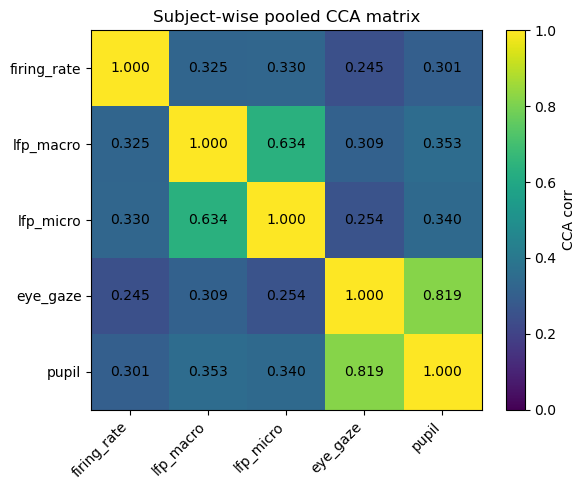

In [ ]:
cca_res = new_fusion.compute_pairwise_cca_subjectwise(
    subject_latent_res,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    n_components=3,
    min_windows=20,
    verbose=True,
)

new_fusion.plot_cca_corr_heatmap_from_matrix(
    cca_res,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    mode="first",
    title="Subject-wise pooled CCA matrix",
)

# new_fusion.plot_cca_pair_scatter(
#     cca_res,
#     "firing_rate",
#     "eye_gaze",
#     comp=1,
# )

[time-PCA] sub=41, modality=firing_rate, X=(1520, 125, 7), Z=(1520, 125, 5)
[time-PCA] sub=42, modality=firing_rate, X=(1520, 125, 50), Z=(1520, 125, 5)
[time-PCA] sub=43, modality=firing_rate, X=(1520, 125, 32), Z=(1520, 125, 5)
[time-PCA] sub=44, modality=firing_rate, X=(1520, 125, 49), Z=(1520, 125, 5)
[time-PCA] sub=47, modality=firing_rate, X=(1520, 125, 75), Z=(1520, 125, 5)
[time-PCA] sub=48, modality=firing_rate, X=(1520, 125, 143), Z=(1520, 125, 5)
[time-PCA] sub=49, modality=firing_rate, X=(1520, 125, 12), Z=(1520, 125, 5)
[time-PCA] sub=51, modality=firing_rate, X=(1520, 125, 30), Z=(1520, 125, 5)
[time-PCA] sub=53, modality=firing_rate, X=(1520, 125, 34), Z=(1520, 125, 5)
[time-PCA] sub=54, modality=firing_rate, X=(1520, 125, 123), Z=(1520, 125, 5)
[time-PCA] sub=55, modality=firing_rate, X=(1520, 125, 57), Z=(1520, 125, 5)
[time-PCA] sub=56, modality=firing_rate, X=(1520, 125, 30), Z=(1520, 125, 5)
[time-PCA] sub=57, modality=firing_rate, X=(1520, 125, 33), Z=(1520, 125, 5

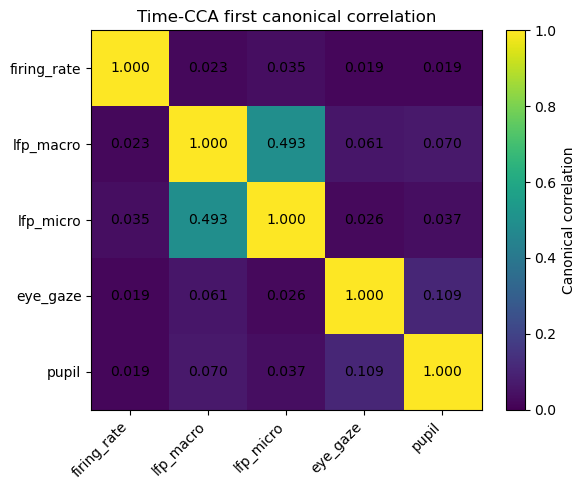

In [ ]:
modality_keys = ["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"]

subject_time_pca_res = new_fusion.run_multimodal_subjectwise_time_trajectory_pca(
    concat_data,
    modality_keys=modality_keys,
    n_components=5,
    sub_col="sub",
    standardize=True,
    verbose=True,
)

time_cca_res = new_fusion.compute_pairwise_time_cca_subjectwise(
    subject_time_pca_res,
    modality_keys=modality_keys,
    n_components=3,
    min_windows=10,
    max_iter=2000,
    verbose=True,
)

new_fusion.plot_time_cca_synergy_matrix(
    time_cca_res,
    modality_keys=modality_keys,
    mode="first",
    title="Time-CCA first canonical correlation"
)

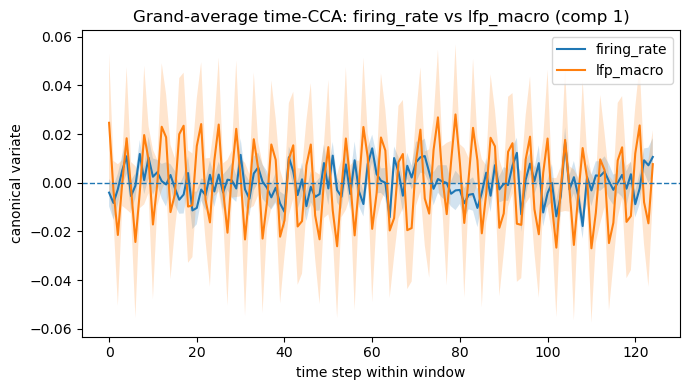

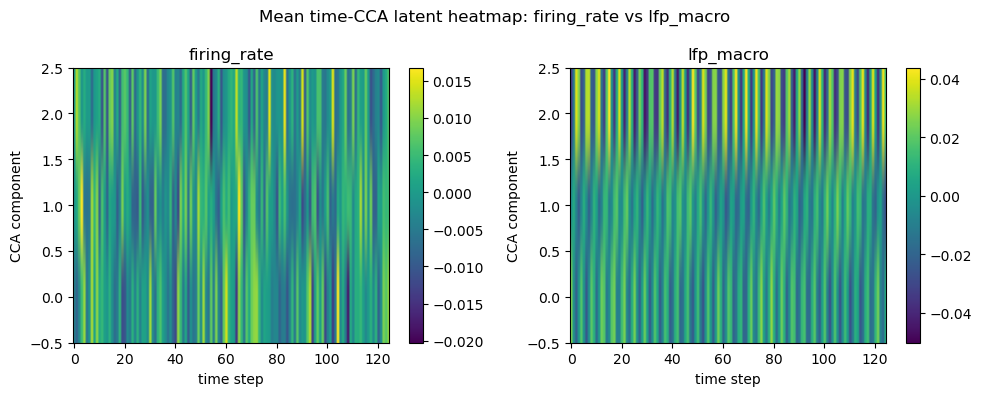

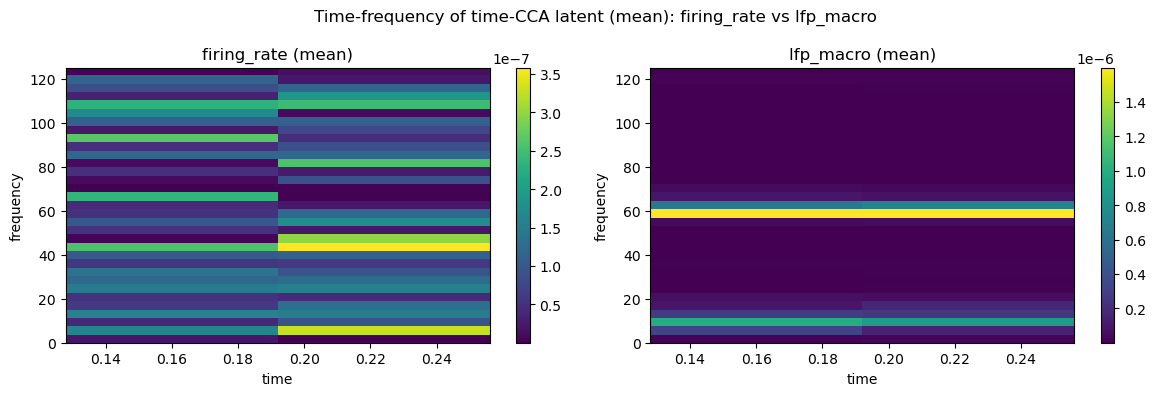

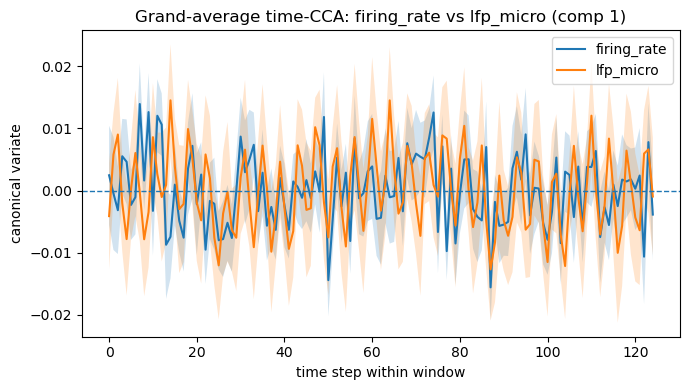

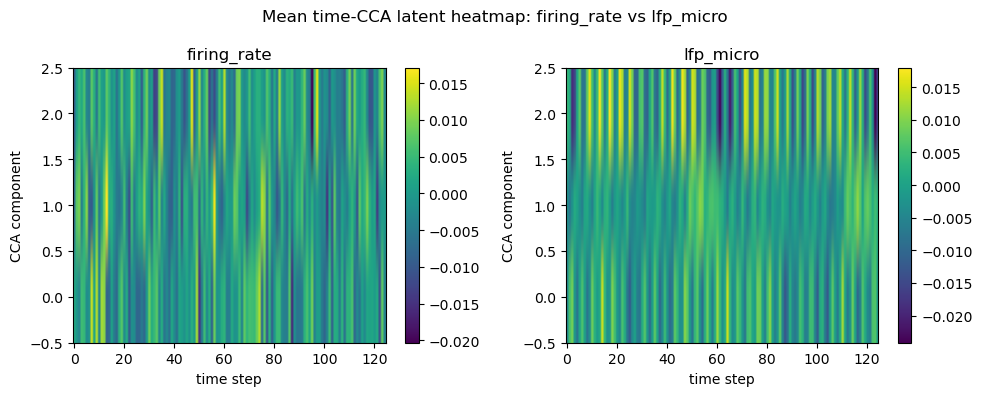

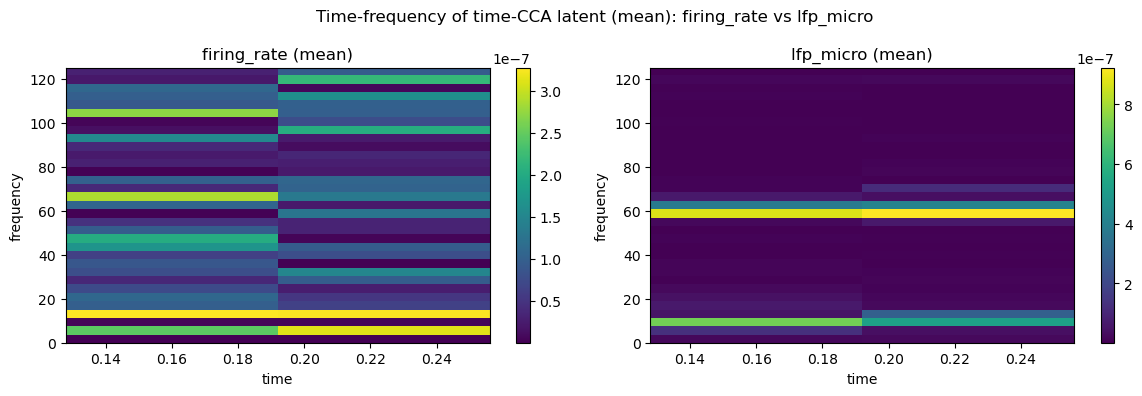

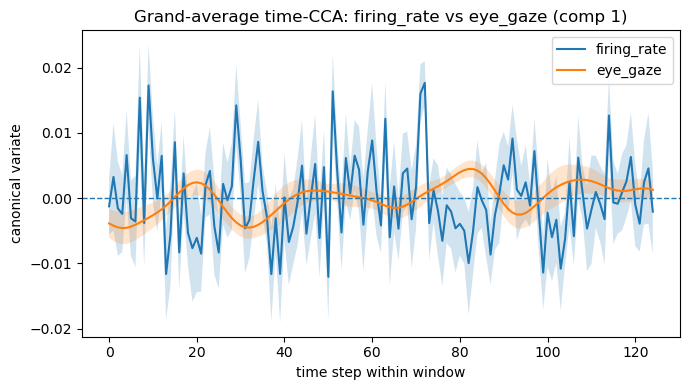

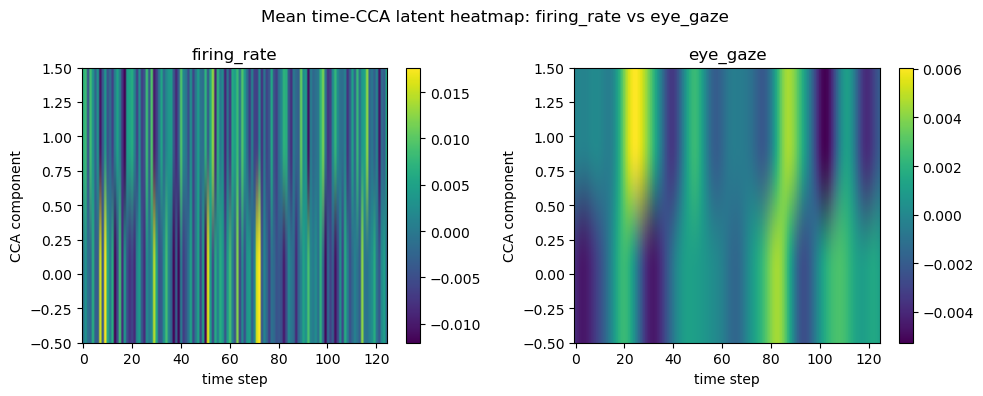

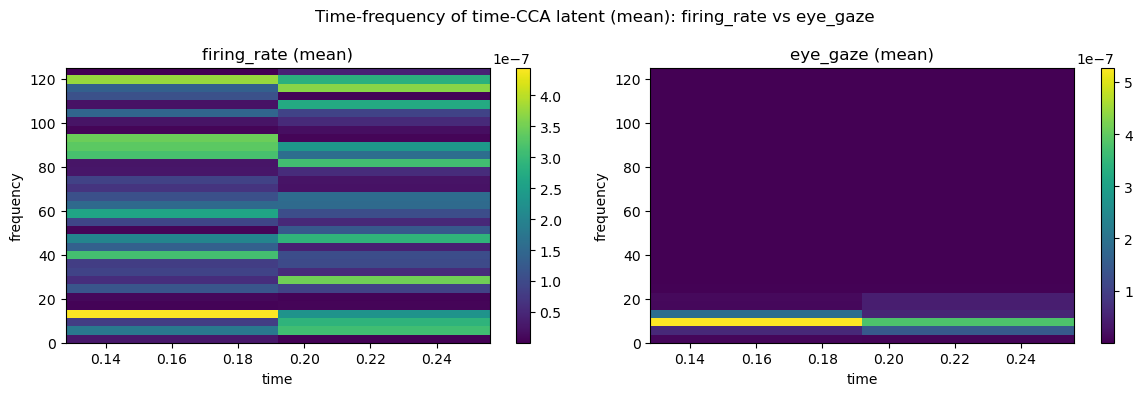

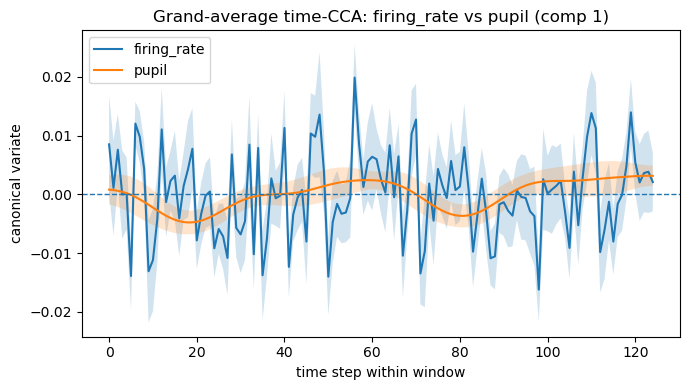

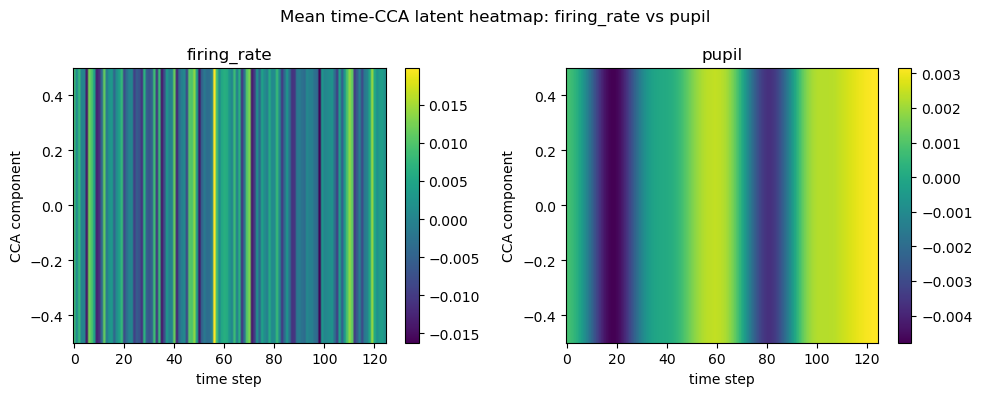

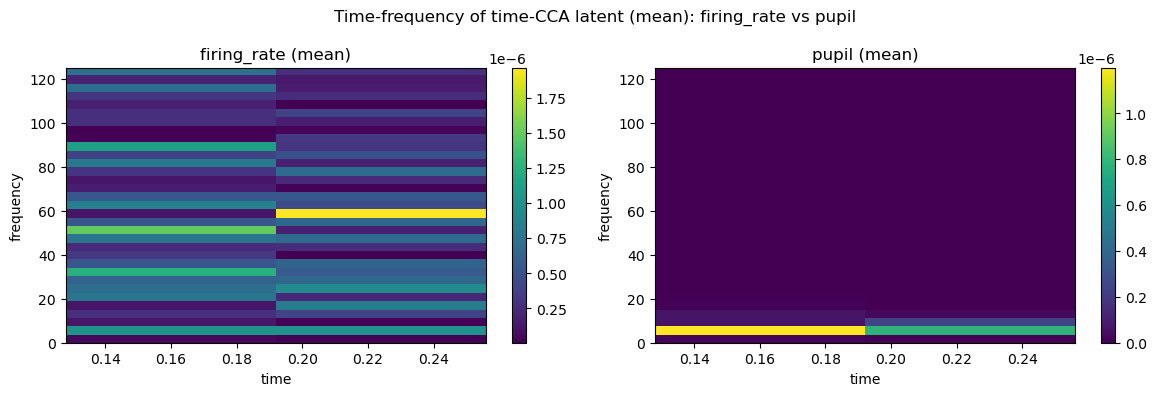

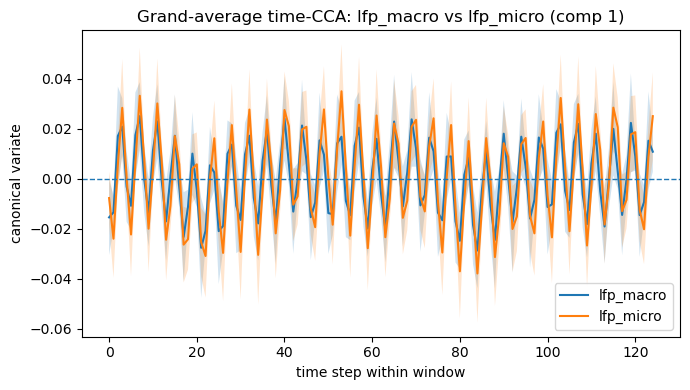

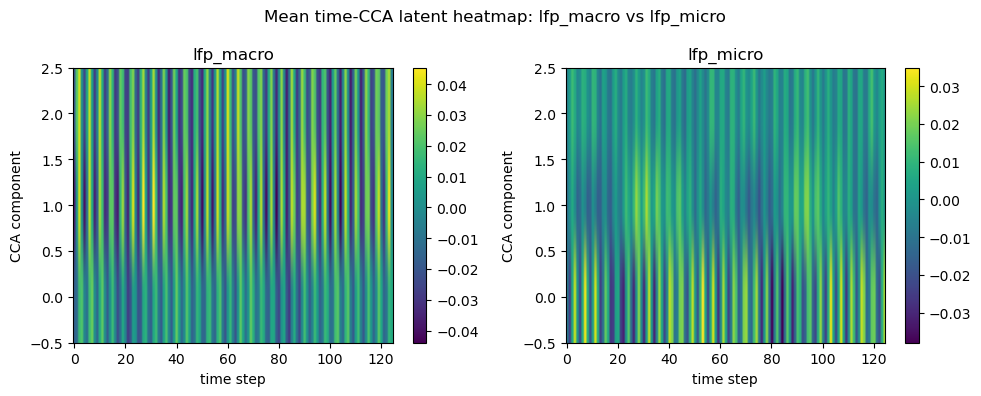

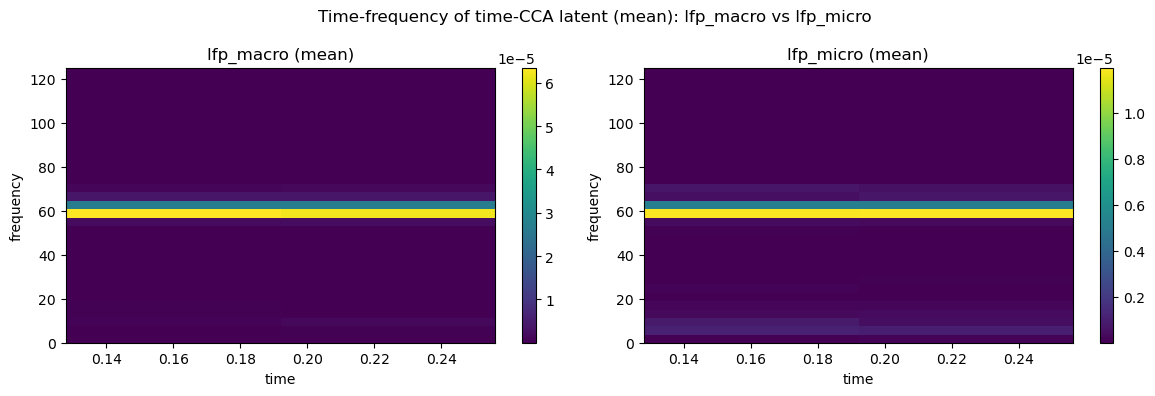

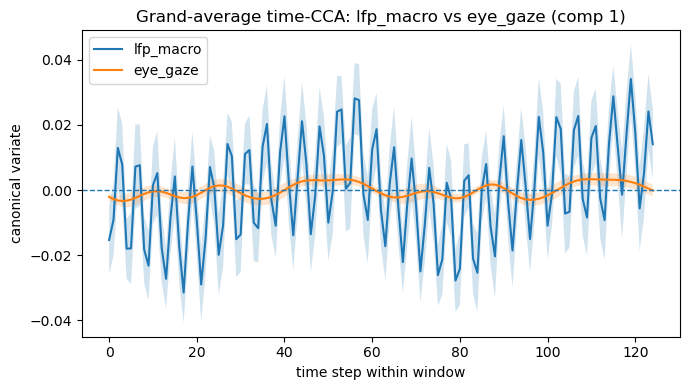

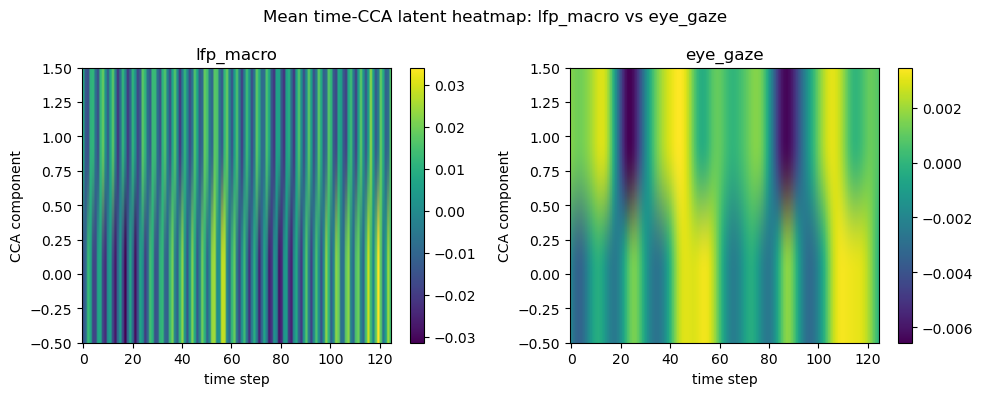

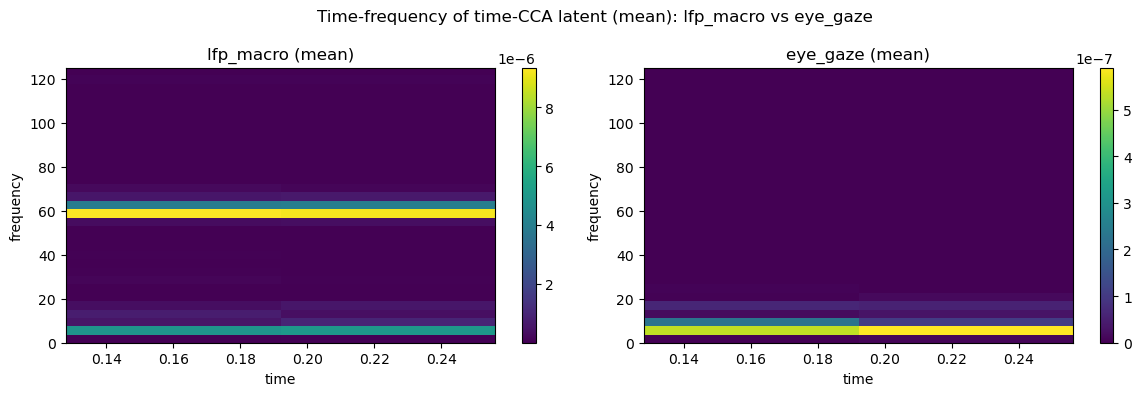

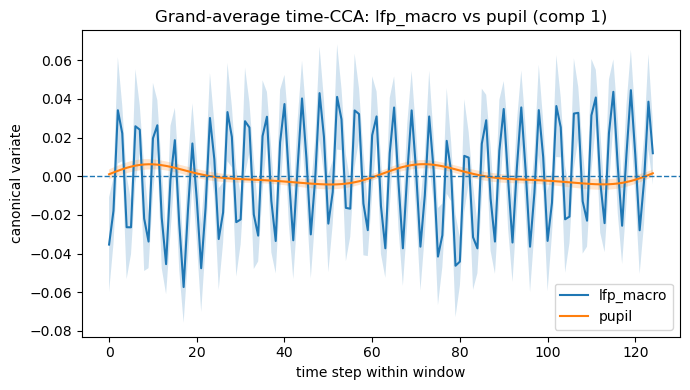

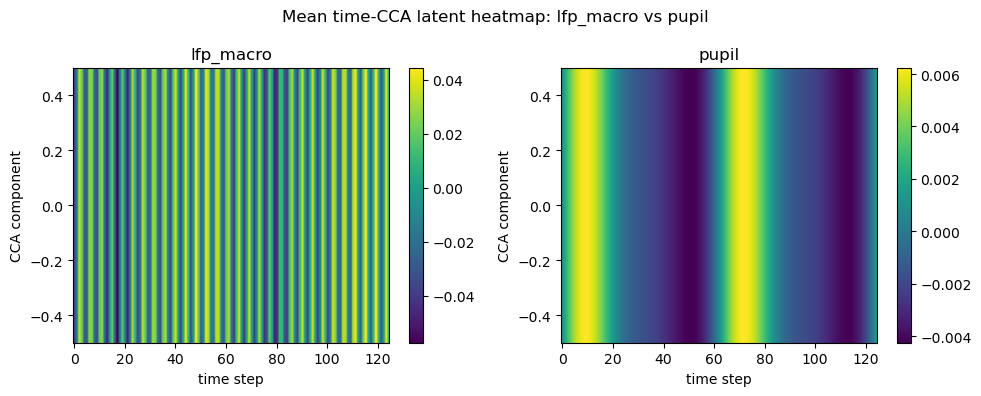

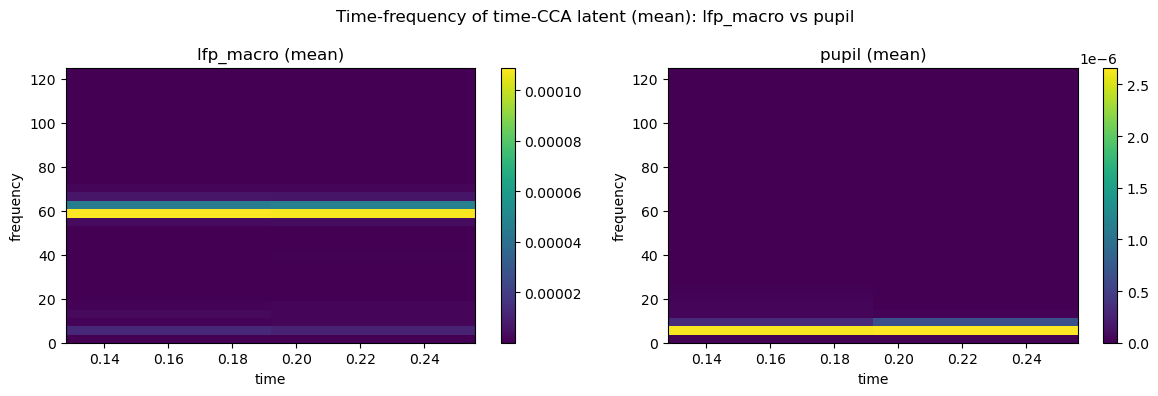

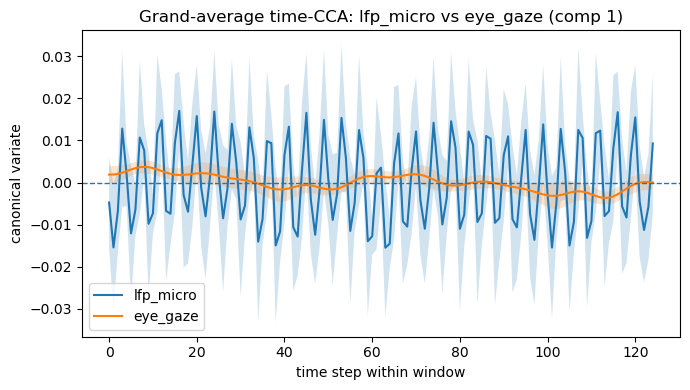

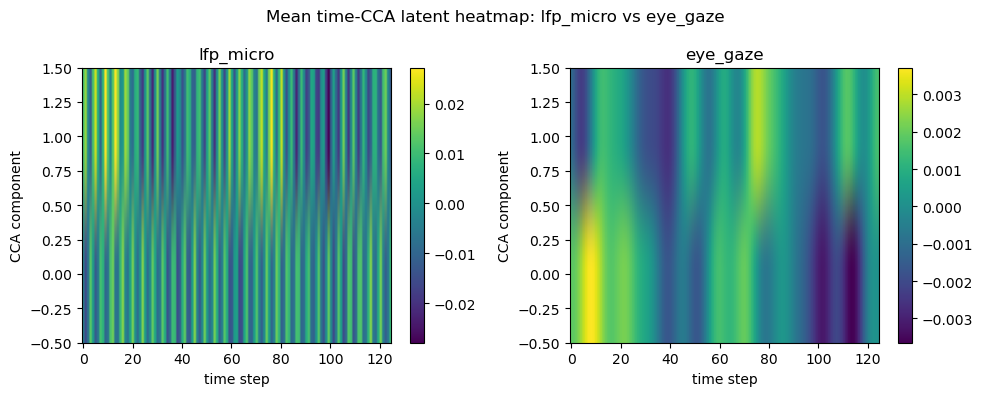

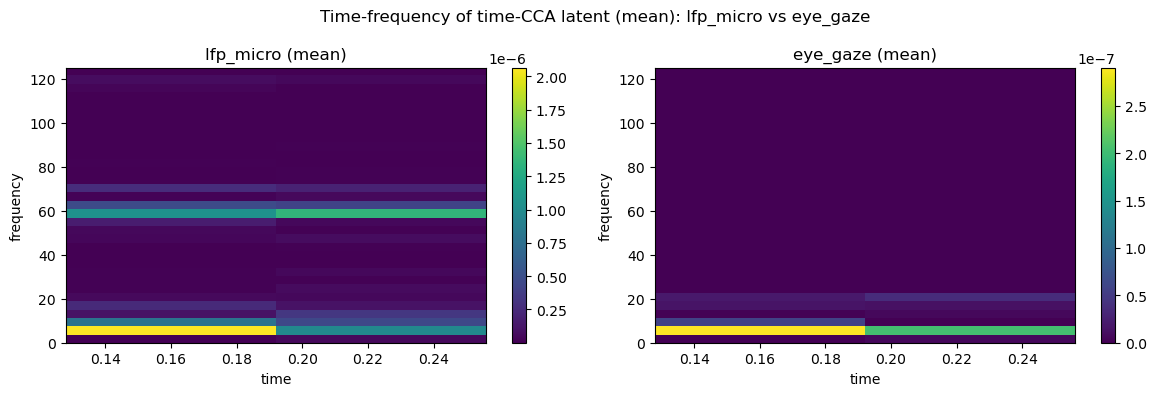

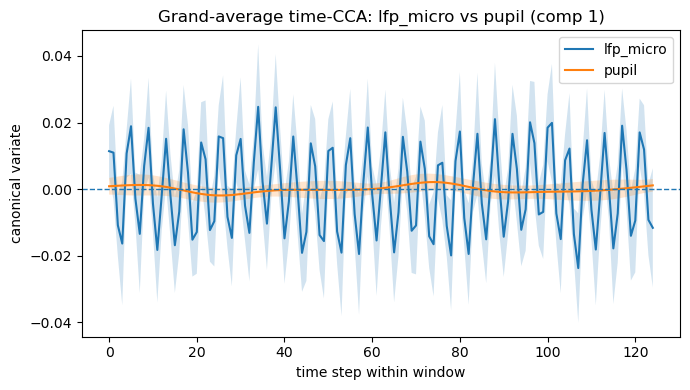

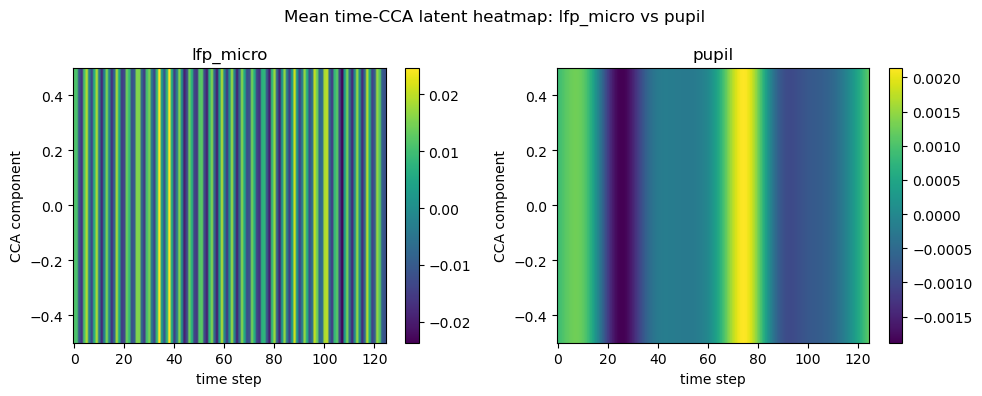

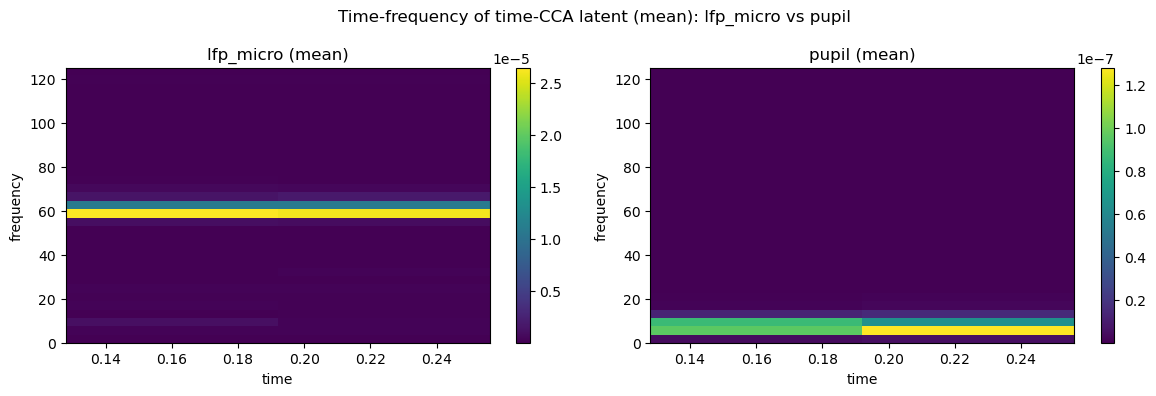

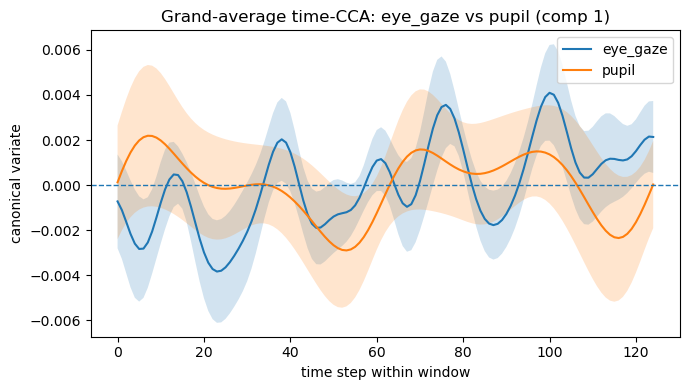

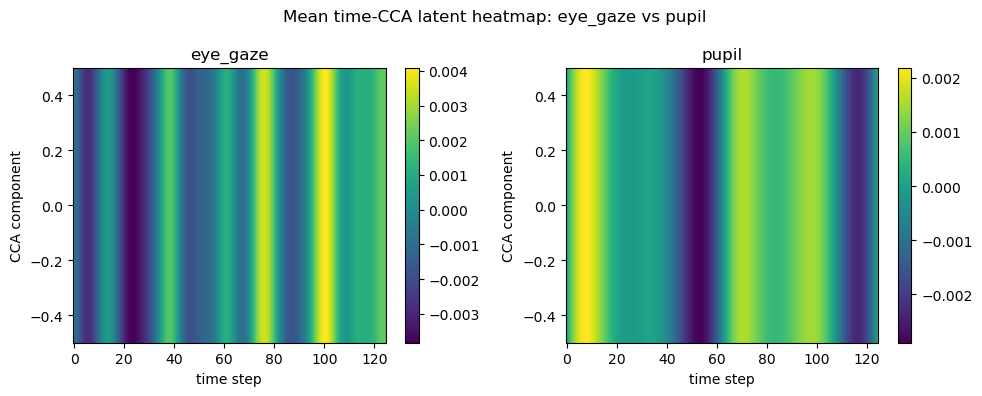

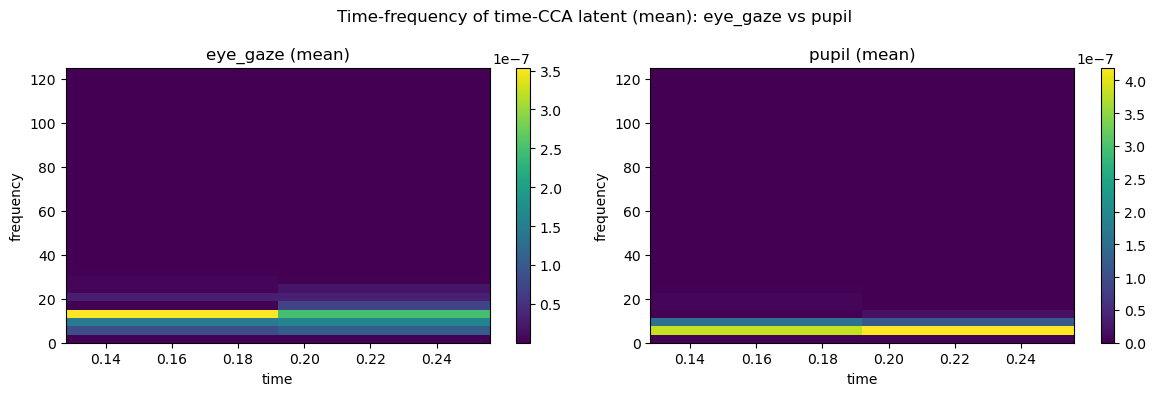

In [ ]:
from itertools import combinations

for m1, m2 in combinations(modality_keys, 2):
    new_fusion.plot_time_cca_grandavg_timeseries(
        time_cca_res,
        m1,
        m2,
        comp=0,
        with_sem=True,
    )

    new_fusion.plot_time_cca_mean_timeseries_heatmap(
        time_cca_res,
        m1,
        m2,
    )

    new_fusion.plot_time_cca_latent_spectrogram(
        time_cca_res,
        m1,
        m2,
        feature_mode="mean",
        which="both",
        fs=250,
        nperseg=16,
        noverlap=8,
    )

In [ ]:
strong_pairs = [
    ("lfp_macro", "lfp_micro"),
    ("lfp_micro", "eye_gaze"),
    ("lfp_macro", "eye_gaze"),
]

In [ ]:
from numpy.linalg import lstsq, eig
from scipy.signal import detrend

def compute_jpca(X, dt):
    """
    X: [T, D]
    dt: scalar
    """
    X = np.asarray(X, dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape={X.shape}")
    if X.shape[0] < 3:
        raise ValueError(f"Need at least 3 time points, got shape={X.shape}")
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError(f"dt must be positive finite, got dt={dt}")

    # 对齐成:
    # X_prev[t] 对应 dX[t] = (X[t+1]-X[t]) / dt
    X_prev = X[:-1]                    # [T-1, D]
    dX = np.diff(X, axis=0) / dt       # [T-1, D]

    # fit: dX = X_prev @ M
    M, _, _, _ = lstsq(X_prev, dX, rcond=None)   # M shape [D, D]

    # 旋转部分
    M_skew = 0.5 * (M - M.T)

    eigvals, eigvecs = eig(M_skew)
    return M, M_skew, eigvals, eigvecs

def project_to_jpca_plane(X, eigvecs, eigvals):
    """
    取虚部最大的那一对特征向量，构造2D jPCA plane
    """
    imag_strength = np.abs(np.imag(eigvals))
    idx = np.argsort(imag_strength)[-2:]

    W = np.real(eigvecs[:, idx])   # [D, 2]
    X_jpca = X @ W                 # [T, 2]
    return X_jpca, W, idx


def plot_jpca_trajectory(X_jpca, modality):
    plt.figure(figsize=(5, 5))
    plt.plot(X_jpca[:, 0], X_jpca[:, 1], linewidth=1)
    plt.scatter(X_jpca[0, 0], X_jpca[0, 1], label="start")
    plt.scatter(X_jpca[-1, 0], X_jpca[-1, 1], label="end")
    plt.xlabel("jPC1")
    plt.ylabel("jPC2")
    plt.title(f"{modality} jPCA plane")
    plt.legend()
    plt.axis("equal")
    plt.show()


def run_jpca_on_result(res, n_input_pc=6):
    X = np.asarray(res["pca_scores"], dtype=np.float64)
    X = detrend(X, axis=0)
    t = np.asarray(res["time"], dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"pca_scores must be 2D, got {X.shape}")
    if len(t) != X.shape[0]:
        raise ValueError(f"time length {len(t)} != X rows {X.shape[0]}")
    if len(t) < 3:
        raise ValueError(f"Need at least 3 time points, got {len(t)}")

    # 去掉非有限时间差
    dt_all = np.diff(t)
    dt_all = dt_all[np.isfinite(dt_all) & (dt_all > 0)]
    if len(dt_all) == 0:
        raise ValueError("No valid positive dt found in time axis")
    dt = np.median(dt_all)

    # 限制输入维数
    k = min(n_input_pc, X.shape[1])
    X = X[:, :k]

    # 去掉含nan的行
    good = np.isfinite(X).all(axis=1) & np.isfinite(t)
    X = X[good]
    t = t[good]

    if X.shape[0] < 3:
        raise ValueError(f"Not enough valid rows after cleaning: {X.shape}")

    M, M_skew, eigvals, eigvecs = compute_jpca(X, dt)
    X_jpca, W, idx = project_to_jpca_plane(X, eigvecs, eigvals)

    plot_jpca_trajectory(X_jpca, res["modality"])

    print(f"{res['modality']} | input_dim={k}, T={X.shape[0]}, dt={dt:.6f}")
    print("eigenvalues:", eigvals)
    print("imag parts:", np.imag(eigvals))

    return {
        "X_jpca": X_jpca,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "W": W,
        "idx": idx,
        "M": M,
        "M_skew": M_skew,
        "dt": dt,
    }

In [ ]:
jpca_results = {}

for modality, res in results.items():
    if res is None:
        continue

    print("\n====", modality, "====")
    try:
        jpca_results[modality] = run_jpca_on_result(res, n_input_pc=6)
    except Exception as e:
        print(f"[skip] {modality}: {e}")

NameError: name 'results' is not defined